# Exploratory Data Analysis - MIT-BIH Arrhythmia Database

CRISP-DM stage 2 (**Data Understanding**). Covers report sections 2.1-2.5.

Prerequisites (from the repo root):
```
python src/download_data.py
python src/prepare_data.py
```
All figures are written to `results/figures/eda_*.png` for use in the report.

**Leakage note:** waveform/morphology analysis uses **DS1 only**. DS2 is only inspected through
header information and class counts, which does not influence modeling decisions.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from scipy import signal as sps
from scipy import stats

from config import class_names, load_config, resolve, split_records, symbol_to_class
from features import FAMILIES, FEATURES, beat_features
from noise import load_noise, noise_power, qrs_power, scaled_noise
from prepare_data import load_record, preprocess_signal

cfg = load_config("configs/data.yaml")
MITDB, NSTDB = resolve(cfg["paths"]["mitdb_dir"]), resolve(cfg["paths"]["nstdb_dir"])
STATS = resolve(cfg["paths"]["stats_dir"])
FIG = resolve("results/figures")
FIG.mkdir(parents=True, exist_ok=True)

CLASSES, MAP, SPLITS = class_names(cfg), symbol_to_class(cfg), split_records(cfg)
DS1, DS2 = sorted(cfg["splits"]["ds1"]), sorted(cfg["splits"]["ds2"])
ALL = sorted(DS1 + DS2)
FS, LEAD = cfg["signal"]["fs"], cfg["signal"]["lead"]
PRE = cfg["window"]["pre_samples"]

# Categorical colours in fixed slot order (identity), recessive grid and axes.
CLASS_COLORS = dict(zip(CLASSES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
SPLIT_COLORS = {"train": "#2a78d6", "val": "#eb6834", "test": "#1baf7a", "excluded": "#898781"}
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "legend.frameon": False,
})


def save(fig, name):
    fig.savefig(FIG / f"eda_{name}.png", dpi=200, bbox_inches="tight")


record_stats = pd.read_csv(STATS / "record_stats.csv")
split_summary = pd.read_csv(STATS / "split_summary.csv")
annotation_mapping = pd.read_csv(STATS / "annotation_mapping.csv")

## 2.1 Dataset description

In [2]:
rows = []
for r in ALL:
    h = wfdb.rdheader(str(MITDB / str(r)))
    tokens = h.comments[0].split() if h.comments else []
    rows.append({
        "record": r, "set": "DS1" if r in DS1 else "DS2", "fs_Hz": h.fs, "n_channels": h.n_sig,
        "n_samples": h.sig_len, "duration_min": round(h.sig_len / h.fs / 60, 2),
        "channel_0": h.sig_name[0], "channel_1": h.sig_name[1],
        "age": tokens[0] if tokens else "", "sex": tokens[1] if len(tokens) > 1 else "",
    })
headers = pd.DataFrame(rows)
db_records = sorted(int(p.stem) for p in MITDB.glob("*.hea") if p.stem.isdigit())

print(f"Records in database: {len(db_records)} | used (DS1 + DS2): {len(ALL)} | not used: {sorted(set(db_records) - set(ALL))}")
print(f"Sampling frequencies: {headers.fs_Hz.unique()} Hz | channels per record: {headers.n_channels.unique()}")
print(f"Duration per record: {headers.duration_min.min()}-{headers.duration_min.max()} min "
      f"| total used: {headers.duration_min.sum() / 60:.1f} h")
print("Lead pairs:", (headers.channel_0 + " / " + headers.channel_1).value_counts().to_dict())
print("Annotations in used records (beat and non-beat):", int(annotation_mapping.total.sum()))
headers

Records in database: 48 | used (DS1 + DS2): 44 | not used: [102, 104, 107, 217]
Sampling frequencies: [360] Hz | channels per record: [2]
Duration per record: 30.09-30.09 min | total used: 22.1 h
Lead pairs: {'MLII / V1': 38, 'MLII / V5': 2, 'MLII / V2': 2, 'V5 / MLII': 1, 'MLII / V4': 1}
Annotations in used records (beat and non-beat): 103650


,record,set,fs_Hz,n_channels,n_samples,duration_min,channel_0,channel_1,age,sex
0,100,DS2,360,2,650000,30.09,MLII,V5,69,M
1,101,DS1,360,2,650000,30.09,MLII,V1,75,F
2,103,DS2,360,2,650000,30.09,MLII,V2,-1,M
3,105,DS2,360,2,650000,30.09,MLII,V1,73,F
4,106,DS1,360,2,650000,30.09,MLII,V1,24,F
5,108,DS1,360,2,650000,30.09,MLII,V1,87,F
6,109,DS1,360,2,650000,30.09,MLII,V1,64,M
7,111,DS2,360,2,650000,30.09,MLII,V1,47,F
8,112,DS1,360,2,650000,30.09,MLII,V1,54,M
9,113,DS2,360,2,650000,30.09,MLII,V1,24,F


## 2.2 Target classes

In [3]:
display(annotation_mapping)
display(split_summary)

,symbol,description,final_class,reason,train,val,excluded,test,total
0,F,Fusion of ventricular and normal beat,F,NaN,385,27,2,388,802
1,N,Normal beat,N,NaN,31854,4596,1624,36415,74489
2,L,Left bundle branch block beat,N,NaN,1457,2490,0,4123,8070
3,R,Right bundle branch block beat,N,NaN,3779,0,0,3473,7252
4,j,Nodal (junctional) escape beat,N,NaN,6,0,10,213,229
5,e,Atrial escape beat,N,NaN,0,16,0,0,16
6,A,Atrial premature contraction,S,NaN,705,75,30,1736,2546
7,a,Aberrated atrial premature beat,S,NaN,2,1,97,50,150
8,J,Nodal (junctional) premature beat,S,NaN,31,0,1,51,83
9,S,Premature or ectopic supraventricular beat,S,NaN,2,0,0,0,2


,split,n_records,records,N,S,V,F,total
0,train,18,101 106 108 112 114 115 116 118 119 122 124 20...,37096,740,3006,385,41227
1,val,3,109 205 223,7102,76,582,27,7787
2,excluded,1,201,1634,128,198,2,1962
3,test,22,100 103 105 111 113 117 121 123 200 202 210 21...,44224,1837,3219,388,49668
4,all,44,NaN,90056,2781,7005,802,100644


## 2.3 Exploratory data analysis
### Example ECG signal

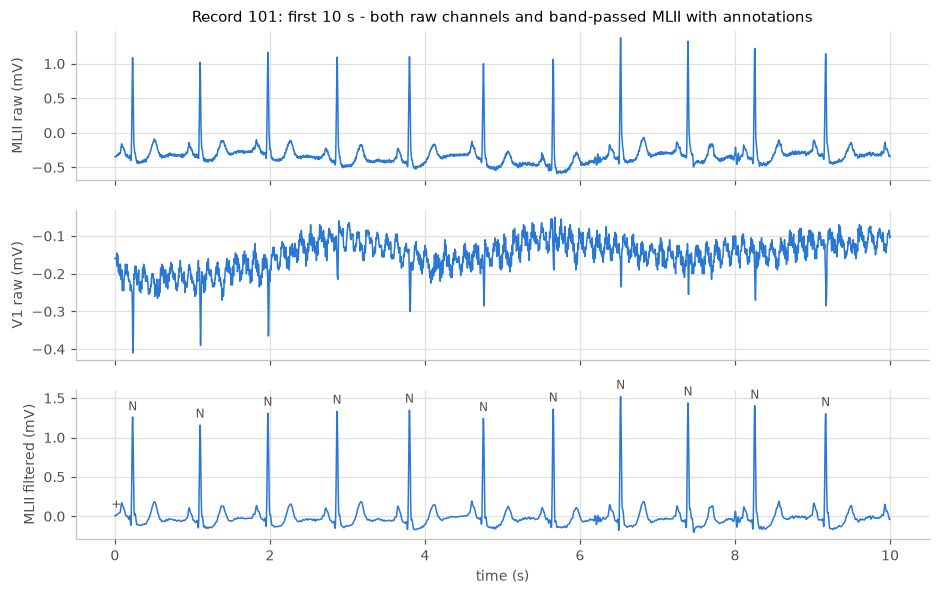

In [4]:
r = DS1[0]
rec = wfdb.rdrecord(str(MITDB / str(r)))
ann = wfdb.rdann(str(MITDB / str(r)), "atr")
seg = slice(0, 10 * FS)
t = np.arange(seg.start, seg.stop) / FS
lead_idx = rec.sig_name.index(LEAD)
x_filt = preprocess_signal(rec.p_signal[:, lead_idx], FS, cfg)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, ch in zip(axes[:2], range(rec.n_sig)):
    ax.plot(t, rec.p_signal[seg, ch], color=CLASS_COLORS["N"], lw=1)
    ax.set_ylabel(f"{rec.sig_name[ch]} raw (mV)")
axes[2].plot(t, x_filt[seg], color=CLASS_COLORS["N"], lw=1)
m = ann.sample < seg.stop
for s, sym in zip(ann.sample[m], np.array(ann.symbol)[m]):
    axes[2].annotate(sym, (s / FS, x_filt[s]), xytext=(0, 5), textcoords="offset points",
                     ha="center", fontsize=8, color=INK2)
axes[2].set_ylabel(f"{LEAD} filtered (mV)")
axes[2].set_xlabel("time (s)")
axes[0].set_title(f"Record {r}: first 10 s - both raw channels and band-passed {LEAD} with annotations")
save(fig, "example_signal")

In [5]:
# QRS peak-to-peak amplitude per lead (first 300 normal beats, +-50 ms around the annotation, trimmed mean)
for ch in range(rec.n_sig):
    amp = np.sqrt(8 * qrs_power(rec.p_signal[:, ch], FS, ann.sample, np.array(ann.symbol)))
    print(f"Record {r} {rec.sig_name[ch]}: {amp:.2f} mV")

Record 101 MLII: 1.73 mV
Record 101 V1: 0.17 mV


### Example heartbeat from each class (DS1)

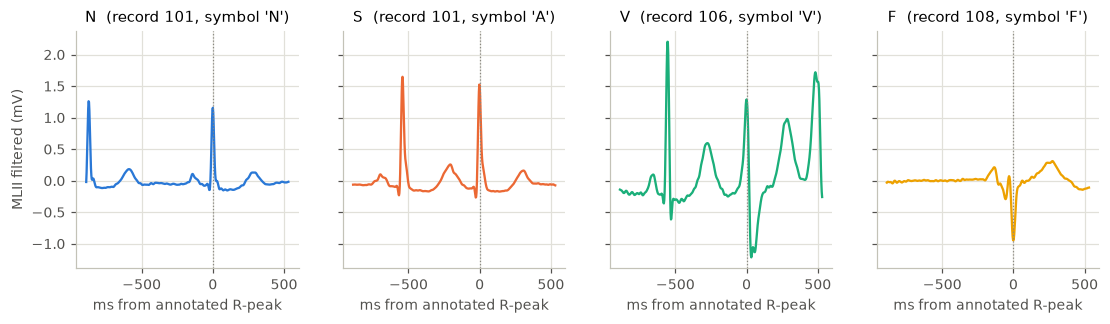

In [6]:
# One raw example per class (first occurrence in DS1), band-pass filtered, in mV.
examples = {}
for r in DS1:
    ann = wfdb.rdann(str(MITDB / str(r)), "atr")
    for s, sym in zip(ann.sample, ann.symbol):
        c = CLASSES[MAP[sym]] if sym in MAP else None
        if c and c not in examples and s > PRE and s < 649_000:
            examples[c] = (r, s, sym)
    if len(examples) == len(CLASSES):
        break

L = PRE + cfg["window"]["post_samples"]
t_ms = (np.arange(L) - PRE) / FS * 1000
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8), sharey=True)
for ax, c in zip(axes, CLASSES):
    r, s, sym = examples[c]
    x, fs, _, _ = load_record(MITDB, r, LEAD)
    xf = preprocess_signal(x, fs, cfg)
    ax.plot(t_ms, xf[s - PRE:s + L - PRE], color=CLASS_COLORS[c], lw=1.5)
    ax.axvline(0, color=MUTED, lw=0.8, ls=":")
    ax.set_title(f"{c}  (record {r}, symbol '{sym}')")
    ax.set_xlabel("ms from annotated R-peak")
axes[0].set_ylabel(f"{LEAD} filtered (mV)")
save(fig, "example_beats_raw")

In [7]:
# Distance from each example beat to its neighbouring R-peaks
for c in CLASSES:
    r, s, sym = examples[c]
    ann = wfdb.rdann(str(MITDB / str(r)), "atr")
    qrs = ann.sample[np.isin(ann.symbol, cfg["qrs_symbols"])]
    k = np.searchsorted(qrs, s)
    print(f"{c} (record {r}): previous R-peak {(qrs[k - 1] - s) / FS * 1000:.0f} ms, next R-peak {(qrs[k + 1] - s) / FS * 1000:+.0f} ms")

N (record 101): previous R-peak -869 ms, next R-peak +875 ms
S (record 101): previous R-peak -539 ms, next R-peak +1183 ms
V (record 106): previous R-peak -556 ms, next R-peak +494 ms
F (record 108): previous R-peak -1611 ms, next R-peak +1128 ms


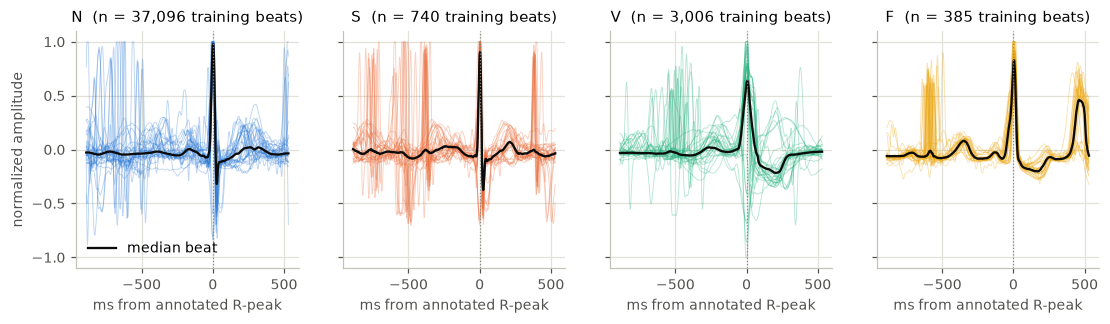

In [8]:
train = np.load(resolve(cfg["paths"]["processed_dir"]) / "train.npz")
X, y = train["X"][:, 0], train["y"]
rng = np.random.default_rng(cfg["seed"])

fig, axes = plt.subplots(1, 4, figsize=(12, 2.8), sharey=True)
for k, (ax, c) in enumerate(zip(axes, CLASSES)):
    idx = np.flatnonzero(y == k)
    for i in rng.choice(idx, min(30, len(idx)), replace=False):
        ax.plot(t_ms, X[i], color=CLASS_COLORS[c], lw=0.6, alpha=0.3)
    ax.plot(t_ms, np.median(X[idx], axis=0), color=INK, lw=1.5, label="median beat")
    ax.axvline(0, color=MUTED, lw=0.8, ls=":")
    ax.set_title(f"{c}  (n = {len(idx):,} training beats)")
    ax.set_xlabel("ms from annotated R-peak")
axes[0].set_ylabel("normalized amplitude")
axes[0].legend(loc="lower left")
save(fig, "example_beats_normalized")

In [9]:
# What the F traces have in common, and where the clip at +-1 acts
f_records = pd.Series(train["record"][y == CLASSES.index("F")]).value_counts()
print("Training F beats per record:", f_records.to_dict())
r = int(f_records.index[0])
ann = wfdb.rdann(str(MITDB / str(r)), "atr")
is_qrs = np.isin(ann.symbol, cfg["qrs_symbols"])
qrs, sym = ann.sample[is_qrs], np.array(ann.symbol)[is_qrs]
k = np.flatnonzero(sym == "F")
k = k[k < len(sym) - 1]
print(f"Record {r}: beat following an F beat: {pd.Series(sym[k + 1]).value_counts().to_dict()}, "
      f"median distance to it {np.median(qrs[k + 1] - qrs[k]) / FS * 1000:.0f} ms")
clipped = np.abs(X) >= 1.0
print("Share of training windows clipped at the R-peak sample:",
      {c: f"{clipped[y == i, PRE].mean():.1%}" for i, c in enumerate(CLASSES)})

Training F beats per record: {208: 372, 124: 5, 114: 4, 108: 2, 203: 1, 215: 1}
Record 208: beat following an F beat: {'V': 292, 'N': 79, 'F': 2}, median distance to it 458 ms
Share of training windows clipped at the R-peak sample: {'N': '49.4%', 'S': '29.1%', 'V': '4.4%', 'F': '11.2%'}


### Class distribution

Share of all beats: {'N': 0.8948, 'S': 0.0276, 'V': 0.0696, 'F': 0.008}
Imbalance ratio N : minority class = {'S': np.float64(32.4), 'V': np.float64(12.9), 'F': np.float64(112.3)}


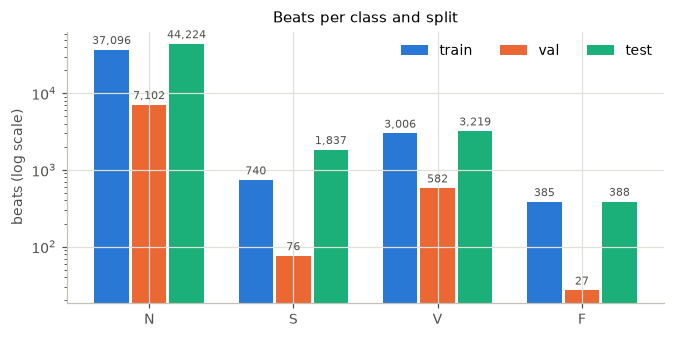

In [10]:
s = split_summary.set_index("split").loc[["train", "val", "test"], CLASSES]
fig, ax = plt.subplots(figsize=(7, 3.2))
width = 0.26
for j, split in enumerate(s.index):
    xs = np.arange(len(CLASSES)) + (j - 1) * width
    bars = ax.bar(xs, s.loc[split], width - 0.02, color=SPLIT_COLORS[split], label=split)
    ax.bar_label(bars, labels=[f"{v:,}" for v in s.loc[split]], fontsize=7, color=INK2, padding=2)
ax.set_yscale("log")
ax.set_xticks(range(len(CLASSES)), CLASSES)
ax.set_ylabel("beats (log scale)")
ax.set_title("Beats per class and split")
ax.legend(ncols=3, loc="upper right")
save(fig, "class_distribution")

tot = split_summary.set_index("split").loc["all", CLASSES]
print("Share of all beats:", (tot / tot.sum()).round(4).to_dict())
print("Imbalance ratio N : minority class =", {c: round(tot["N"] / tot[c], 1) for c in CLASSES[1:]})

### Subject / record distribution

Records containing each class: {'N': 44, 'S': 32, 'V': 33, 'F': 17}
Share of each class contributed by its largest record:
  N: record 215 (train) holds 4% of all N beats
  S: record 232 (test) holds 50% of all S beats
  V: record 208 (train) holds 14% of all V beats
  F: record 208 (train) holds 46% of all F beats


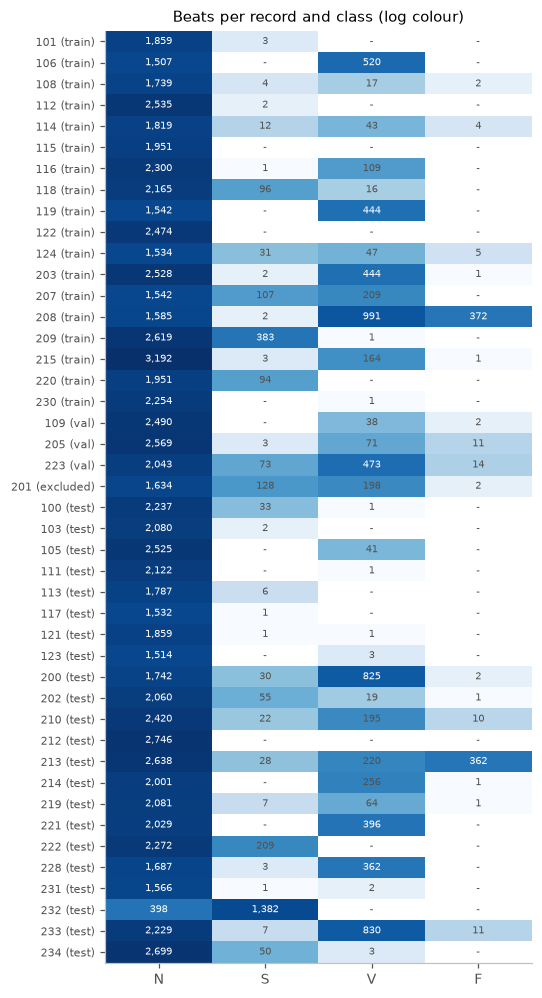

In [11]:
rs = record_stats.assign(order=record_stats.split.map({"train": 0, "val": 1, "excluded": 2, "test": 3})).sort_values(["order", "record"])
counts = rs[CLASSES].to_numpy()
fig, ax = plt.subplots(figsize=(5, 11))
ax.imshow(np.where(counts > 0, counts, np.nan), aspect="auto", cmap="Blues", norm=LogNorm(1, counts.max()))
for i in range(counts.shape[0]):
    for j in range(counts.shape[1]):
        v = counts[i, j]
        ax.text(j, i, f"{v:,}" if v else "-", ha="center", va="center", fontsize=6.5,
                color="white" if v > 300 else INK2)
ax.set_xticks(range(len(CLASSES)), CLASSES)
ax.set_yticks(range(len(rs)), [f"{r} ({s})" for r, s in zip(rs.record, rs.split)], fontsize=7)
ax.grid(False)
ax.set_title("Beats per record and class (log colour)")
save(fig, "record_distribution")

print("Records containing each class:", {c: int((rs[c] > 0).sum()) for c in CLASSES})
print("Share of each class contributed by its largest record:")
for c in CLASSES:
    top = rs.loc[rs[c].idxmax()]
    print(f"  {c}: record {top.record} ({top.split}) holds {top[c] / rs[c].sum():.0%} of all {c} beats")

### Signal amplitude distribution

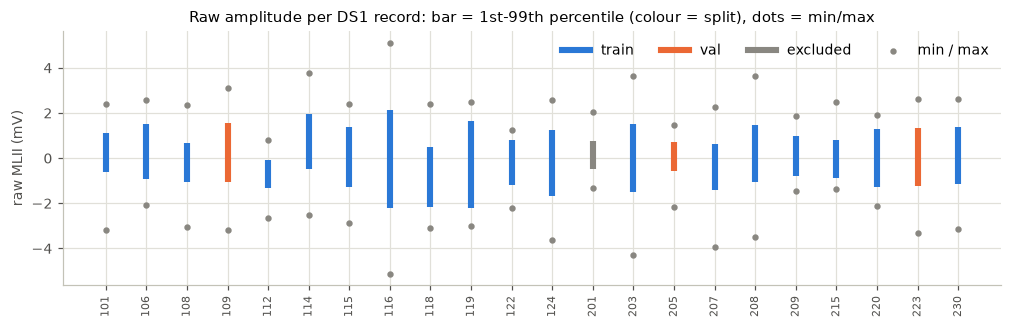

In [12]:
# Per-record raw amplitude range (DS1 records only, statistics from prepare_data.py)
rs = record_stats[record_stats.record.isin(DS1)].sort_values("record")
fig, ax = plt.subplots(figsize=(11, 3))
xs = np.arange(len(rs))
colors = [SPLIT_COLORS[s] for s in rs.split]
ax.vlines(xs, rs.raw_p1_mV, rs.raw_p99_mV, color=colors, lw=4)
extremes = ax.scatter(xs, rs.raw_min_mV, s=10, color=MUTED, zorder=3, label="min / max")
ax.scatter(xs, rs.raw_max_mV, s=10, color=MUTED, zorder=3)
ax.set_xticks(xs, rs.record, rotation=90, fontsize=7)
ax.set_ylabel(f"raw {LEAD} (mV)")
ax.set_title("Raw amplitude per DS1 record: bar = 1st-99th percentile (colour = split), dots = min/max")
handles = [plt.Line2D([], [], color=SPLIT_COLORS[s], lw=4, label=s) for s in ("train", "val", "excluded")]
ax.legend(handles=handles + [extremes], ncols=4, loc="upper right")
save(fig, "amplitude_per_record")

,N,S,V,F
count,45866.000,944.000,3788.000,415.000
mean,1.423,1.048,0.973,1.739
std,0.801,0.945,1.448,0.629
min,-2.146,-1.547,-3.178,-2.327
25%,1.030,0.886,0.335,1.577
50%,1.490,1.304,1.262,1.824
75%,1.931,1.578,1.733,2.097
max,3.749,3.322,4.010,2.742


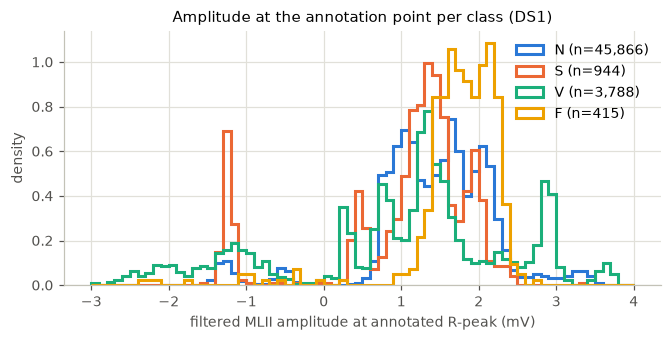

In [13]:
# R-peak amplitude (band-passed) per class - DS1 only
r_amp = {c: [] for c in CLASSES}
filtered_ds1 = {}
for r in DS1:
    x, fs, samples, symbols = load_record(MITDB, r, LEAD)
    xf = preprocess_signal(x, fs, cfg)
    filtered_ds1[r] = (x, xf, samples, symbols)
    for s, sym in zip(samples, symbols):
        if sym in MAP:
            r_amp[CLASSES[MAP[sym]]].append(xf[s])

fig, ax = plt.subplots(figsize=(7, 3))
bins = np.linspace(-3, 4, 71)
for c in CLASSES:
    ax.hist(r_amp[c], bins=bins, density=True, histtype="step", lw=2, color=CLASS_COLORS[c], label=f"{c} (n={len(r_amp[c]):,})")
ax.set_xlabel(f"filtered {LEAD} amplitude at annotated R-peak (mV)")
ax.set_ylabel("density")
ax.set_title("Amplitude at the annotation point per class (DS1)")
ax.legend()
save(fig, "rpeak_amplitude_per_class")
pd.DataFrame({c: pd.Series(v).describe() for c, v in r_amp.items()}).round(3)

In [14]:
# Per-record median R-peak amplitude: spread between records versus difference between classes
amp = pd.DataFrame([(r, CLASSES[MAP[sym]], xf[s]) for r, (_, xf, samples, symbols) in filtered_ds1.items()
                    for s, sym in zip(samples, symbols) if sym in MAP], columns=["record", "class", "amplitude"])
print("Class medians (mV):", amp.groupby("class").amplitude.median().round(2).to_dict())
per_record = amp.groupby(["record", "class"]).amplitude.median().unstack()[CLASSES]
print("Range of per-record medians (mV):", {c: (float(per_record[c].min().round(2)), float(per_record[c].max().round(2))) for c in CLASSES})
per_record.round(2)

Class medians (mV): {'F': 1.82, 'N': 1.49, 'S': 1.3, 'V': 1.26}
Range of per-record medians (mV): {'N': (-1.27, 3.02), 'S': (-1.24, 3.32), 'V': (-2.3, 3.61), 'F': (-2.19, 2.13)}


class,N,S,V,F
record,,,,
101,1.53,1.57,NaN,NaN
106,2.01,NaN,1.14,NaN
108,0.34,0.71,0.41,-0.99
109,1.71,NaN,0.64,1.68
112,0.77,0.76,NaN,NaN
114,2.00,1.75,-2.19,-2.19
115,2.08,NaN,NaN,NaN
116,3.02,3.32,3.61,NaN
118,1.33,1.51,1.78,NaN


### Examples of noisy ECG

Record 101: QRS peak-to-peak amplitude 1.73 mV. RMS of the added noise and of what remains after the band-pass:


,noise,snr_db,added_rms_mV,after_filter_rms_mV
0,bw,12,0.70,0.08
1,bw,6,1.39,0.16
2,bw,0,2.77,0.33
3,em,12,0.33,0.23
4,em,6,0.65,0.47
5,em,0,1.30,0.93
6,ma,12,0.34,0.14
7,ma,6,0.68,0.29
8,ma,0,1.37,0.58


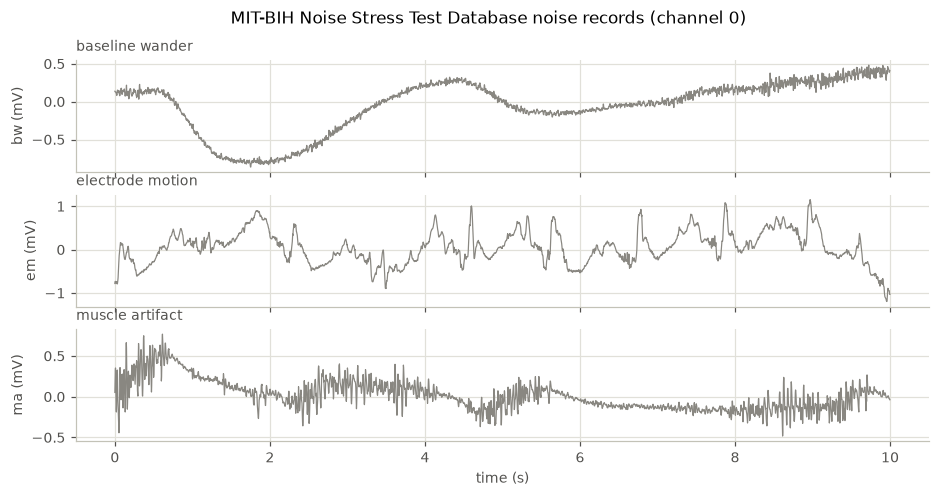

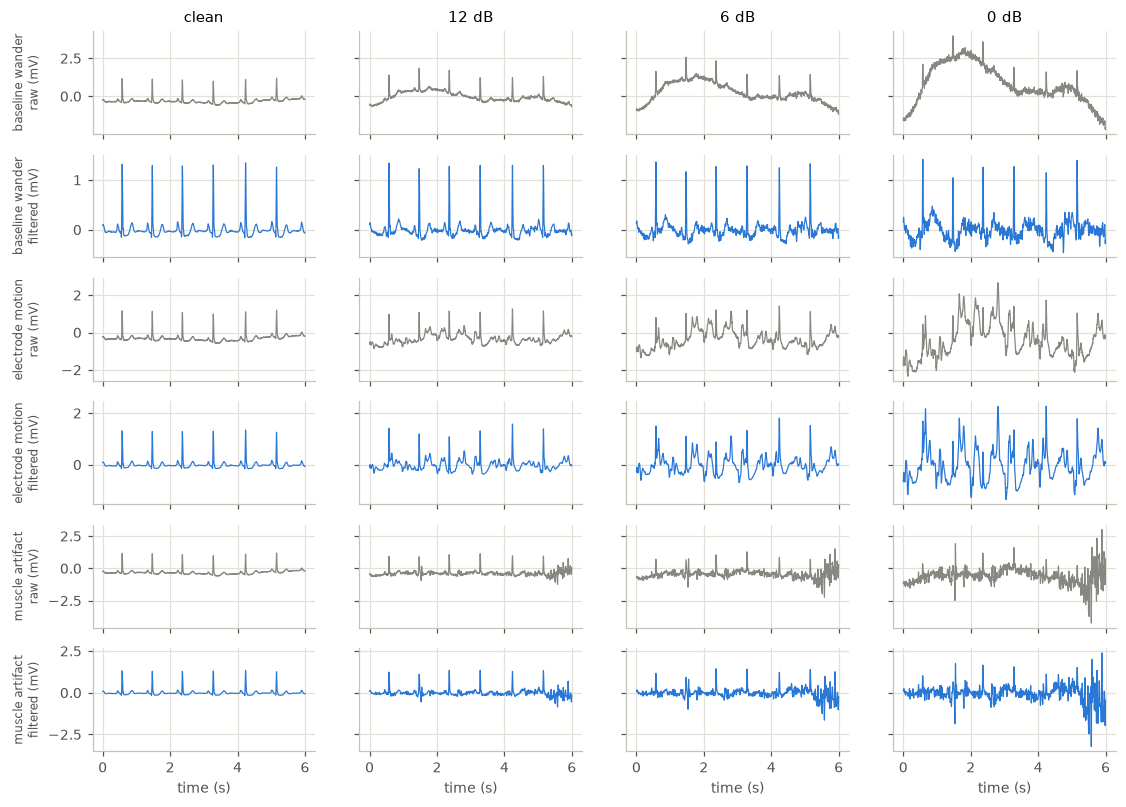

In [15]:
# NSTDB noise types (training part of each noise record only) and a clean DS1 record with added noise
r = DS1[0]
x, xf = filtered_ds1[r][:2]
seg = slice(60 * FS, 70 * FS)
t = np.arange(seg.stop - seg.start) / FS
rng = np.random.default_rng(cfg["seed"])

fig, axes = plt.subplots(3, 1, figsize=(10, 4.5), sharex=True)
for ax, (ntype, desc) in zip(axes, cfg["noise"]["types"].items()):
    n = load_noise(cfg, ntype, part="train")
    ax.plot(t, n[seg], color=MUTED, lw=0.8)
    ax.set_ylabel(f"{ntype} (mV)")
    ax.set_title(desc, loc="left", fontsize=9, color=INK2)
axes[-1].set_xlabel("time (s)")
fig.suptitle("MIT-BIH Noise Stress Test Database noise records (channel 0)")
save(fig, "nstdb_noise")

# Record r with each noise type at every SNR (SNR as defined by the WFDB nst tool, see src/noise.py).
# Rows: noise type, raw and after the band-pass. Columns: clean, then increasing noise. The same stretch of
# each noise record is used at every SNR, so only the gain changes along a row.
seg = slice(60 * FS, 66 * FS)
t = np.arange(seg.stop - seg.start) / FS
s_power = qrs_power(x, FS, *filtered_ds1[r][2:])
noise_powers = {ntype: noise_power(cfg, ntype) for ntype in cfg["noise"]["types"]}
em_power = noise_powers["em"]
levels = [None] + cfg["noise"]["snr_db"]
fig, axes = plt.subplots(6, len(levels), figsize=(12, 8.5), sharex=True, sharey="row")
residual = []
for i, (ntype, desc) in enumerate(cfg["noise"]["types"].items()):
    n = load_noise(cfg, ntype, part="train")
    for j, snr in enumerate(levels):
        added = np.zeros_like(x) if snr is None else scaled_noise(n, len(x), s_power, noise_powers[ntype], snr,
                                                                  np.random.default_rng(cfg["seed"]))
        filtered = preprocess_signal(x + added, FS, cfg)
        axes[2 * i, j].plot(t, (x + added)[seg], color=MUTED, lw=0.8)
        axes[2 * i + 1, j].plot(t, filtered[seg], color=CLASS_COLORS["N"], lw=0.8)
        if snr is not None:
            residual.append({"noise": ntype, "snr_db": snr, "added_rms_mV": added.std(),
                             "after_filter_rms_mV": (filtered - xf).std()})
    axes[2 * i, 0].set_ylabel(f"{desc}\nraw (mV)", fontsize=8)
    axes[2 * i + 1, 0].set_ylabel(f"{desc}\nfiltered (mV)", fontsize=8)
for j, snr in enumerate(levels):
    axes[0, j].set_title("clean" if snr is None else f"{snr} dB")
    axes[-1, j].set_xlabel("time (s)")
fig.align_ylabels(axes[:, 0])
save(fig, "noisy_ecg_snr")
print(f"Record {r}: QRS peak-to-peak amplitude {np.sqrt(8 * s_power):.2f} mV. RMS of the added noise and of what remains after the band-pass:")
pd.DataFrame(residual).round(2)

In [16]:
# Share of each noise type's power inside the 0.5-40 Hz pass band of the preprocessing filter
for ntype in cfg["noise"]["types"]:
    n = load_noise(cfg, ntype, part="train")
    print(f"{ntype}: {preprocess_signal(n, FS, cfg).var() / n.var():.1%} of the noise power passes the band-pass filter")

bw: 1.5% of the noise power passes the band-pass filter
em: 53.4% of the noise power passes the band-pass filter
ma: 18.1% of the noise power passes the band-pass filter


In [17]:
# Check of the SNR definition against the database itself: nst generated records 118eXX / 119eXX as
# clean record + gain * em, with the noise switched on in two-minute segments after the first five minutes.
# The gain fitted in the first noisy segment should equal the gain src/noise.py computes for the same SNR.
em_raw = wfdb.rdrecord(str(NSTDB / "em")).p_signal[:, cfg["noise"]["channel"]]
noisy_seg = slice(5 * 60 * FS + 2 * FS, 7 * 60 * FS - 2 * FS)
rows = []
for r in (118, 119):
    x, _, samples, symbols = filtered_ds1[r]
    s_power = qrs_power(x, FS, samples, symbols)
    for tag, snr in [("e24", 24), ("e18", 18), ("e12", 12), ("e06", 6), ("e00", 0), ("e_6", -6)]:
        added = wfdb.rdrecord(str(NSTDB / f"{r}{tag}")).p_signal[noisy_seg, 0] - x[noisy_seg]
        gain_nst = np.polyfit(em_raw[noisy_seg], added, 1)[0]
        gain_ours = np.sqrt(s_power / (em_power * 10 ** (snr / 10)))
        rows.append({"record": f"{r}{tag}", "snr_db": snr, "gain_nst": gain_nst, "gain_ours": gain_ours,
                     "difference_db": 20 * np.log10(gain_ours / gain_nst)})
snr_check = pd.DataFrame(rows)
print(f"Largest deviation from the nst gain: {snr_check.difference_db.abs().max():.2f} dB")
snr_check.round(3)

Largest deviation from the nst gain: 0.05 dB


,record,snr_db,gain_nst,gain_ours,difference_db
0,118e24,24,0.187,0.186,-0.049
1,118e18,18,0.373,0.371,-0.048
2,118e12,12,0.743,0.739,-0.044
3,118e06,6,1.483,1.475,-0.045
4,118e00,0,2.960,2.944,-0.048
5,118e_6,-6,5.908,5.874,-0.051
6,119e24,24,0.162,0.161,-0.055
7,119e18,18,0.323,0.321,-0.051
8,119e12,12,0.644,0.640,-0.045
9,119e06,6,1.284,1.277,-0.044


'~' quality annotations in DS1: 289, marking MLII noisy: 69, unreadable: 3
Noisy/unreadable marks per record: {101: 2, 108: 11, 112: 2, 116: 4, 118: 4, 201: 2, 203: 29, 207: 5, 208: 9, 215: 3, 223: 1}


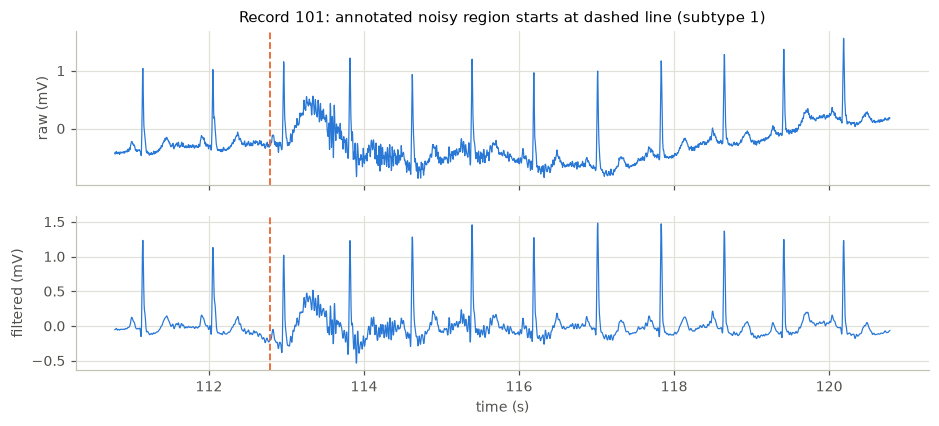

In [18]:
# Naturally noisy regions: signal-quality annotations ('~'). WFDB convention for the subtype field:
# bit k = signal k noisy, bit k+4 = signal k unreadable, -1 = all signals unreadable, 0 = clean again.
quality = []
for r in DS1:
    ann = wfdb.rdann(str(MITDB / str(r)), "atr")
    ch = wfdb.rdheader(str(MITDB / str(r))).sig_name.index(LEAD)
    for s, sym, sub in zip(ann.sample, ann.symbol, ann.subtype):
        if sym == "~":
            sub = int(sub)
            quality.append({"record": r, "sample": s, "subtype": sub,
                            "noisy": sub > 0 and bool(sub & (1 << ch)),
                            "unreadable": sub == -1 or (sub > 0 and bool(sub & (1 << (ch + 4))))})
quality = pd.DataFrame(quality)
noisy_marks = quality[quality.noisy | quality.unreadable]
print(f"'~' quality annotations in DS1: {len(quality)}, marking {LEAD} noisy: {int(quality.noisy.sum())}, "
      f"unreadable: {int(quality.unreadable.sum())}")
print("Noisy/unreadable marks per record:", noisy_marks.groupby("record").size().to_dict())

if len(noisy_marks):
    r, s = noisy_marks.iloc[0][["record", "sample"]]
    x, xf, samples, symbols = filtered_ds1[int(r)]
    seg = slice(max(0, s - 2 * FS), s + 8 * FS)
    t = np.arange(seg.start, seg.stop) / FS
    fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
    axes[0].plot(t, x[seg], color=CLASS_COLORS["N"], lw=0.8)
    axes[1].plot(t, xf[seg], color=CLASS_COLORS["N"], lw=0.8)
    for ax in axes:
        ax.axvline(s / FS, color=CLASS_COLORS["S"], lw=1.2, ls="--")
    axes[0].set_ylabel("raw (mV)")
    axes[1].set_ylabel("filtered (mV)")
    axes[1].set_xlabel("time (s)")
    axes[0].set_title(f"Record {int(r)}: annotated noisy region starts at dashed line (subtype {noisy_marks.iloc[0].subtype})")
    save(fig, "natural_noise_example")

### Signal measures and features (DS1)

A broad survey of signal measures, each computed per beat on the filtered MLII signal of the DS1 records
(`src/features.py`): amplitude statistics, shape and complexity, QRS morphology, rhythm, spectrum, wavelet
energies, measures relative to the other beats of the same record, and measures of the prepared beat window.
The measures describe the signals and are candidate inputs for a classifier.

For every measure and every minority class, separability from N is the area under the ROC curve of that single
measure (0.5 = no separation, 1.0 = complete), computed twice: with all DS1 beats **pooled**, and **within**
each record that has at least 10 beats of both classes (median over those records).

Median share of raw ECG power per band (DS1 records): below 0.5 Hz 8.2%, 0.5-40 Hz 90.6%, above 40 Hz 0.3%
Power-line peak at 60 Hz: 9 times the level at 45-55 Hz


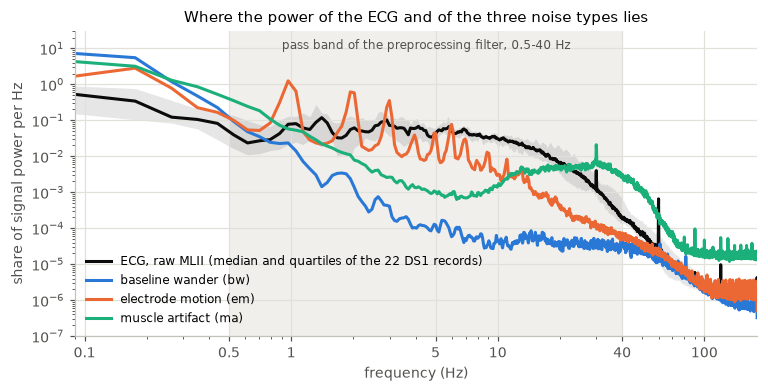

In [19]:
# Power spectral density of the raw ECG and of the three noise types (Welch, 11 s segments), each scaled to unit power
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
NOISE_COLORS = dict(zip(cfg["noise"]["types"], ["#2a78d6", "#eb6834", "#1baf7a"]))


def relative_psd(x):
    f, p = sps.welch(x, FS, nperseg=4096, noverlap=2048)
    return f[1:], p[1:] / np.trapezoid(p[1:], f[1:])


psd = np.array([relative_psd(x)[1] for x, _, _, _ in filtered_ds1.values()])
freq = relative_psd(filtered_ds1[DS1[0]][0])[0]

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.axvspan(cfg["signal"]["bandpass"]["low_hz"], cfg["signal"]["bandpass"]["high_hz"], color="#f0efec", lw=0, zorder=0)
ax.fill_between(freq, np.percentile(psd, 25, axis=0), np.percentile(psd, 75, axis=0), color=INK, alpha=0.10, lw=0)
ax.plot(freq, np.median(psd, axis=0), color=INK, lw=2, label="ECG, raw MLII (median and quartiles of the 22 DS1 records)")
for ntype, desc in cfg["noise"]["types"].items():
    ax.plot(*relative_psd(load_noise(cfg, ntype, part="train")), color=NOISE_COLORS[ntype], lw=2, label=f"{desc} ({ntype})")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.09, 180)
ax.set_ylim(1e-7, 30)
ax.set_xticks([0.1, 0.5, 1, 5, 10, 40, 100], ["0.1", "0.5", "1", "5", "10", "40", "100"])
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("share of signal power per Hz")
ax.text(4.5, 12, "pass band of the preprocessing filter, 0.5-40 Hz", ha="center", va="center", fontsize=8, color=INK2)
ax.set_title("Where the power of the ECG and of the three noise types lies")
ax.legend(loc="lower left", fontsize=8)
save(fig, "psd_ecg_noise")


def band_share(p, lo, hi):
    m = (freq >= lo) & (freq < hi)
    return np.trapezoid(p[m], freq[m])


print("Median share of raw ECG power per band (DS1 records): "
      f"below 0.5 Hz {np.median([band_share(p, 0, 0.5) for p in psd]):.1%}, "
      f"0.5-40 Hz {np.median([band_share(p, 0.5, 40) for p in psd]):.1%}, "
      f"above 40 Hz {np.median([band_share(p, 40, 181) for p in psd]):.1%}")
med = np.median(psd, axis=0)
print(f"Power-line peak at 60 Hz: {med[(freq > 59) & (freq < 61)].max() / np.median(med[(freq > 45) & (freq < 55)]):.0f} "
      "times the level at 45-55 Hz")

In [20]:
# All signal measures for every DS1 beat (same beats as train.npz + val.npz)
feat = pd.concat([beat_features(xf, FS, samples, symbols, cfg).assign(record=r)
                  for r, (_, xf, samples, symbols) in filtered_ds1.items()], ignore_index=True)
print(f"{len(feat):,} beats x {len(FEATURES)} measures | per family:",
      pd.Series([family for family, _ in FEATURES.values()]).value_counts().reindex(FAMILIES).to_dict())
print("Share of beats whose previous R-peak lies inside the 512-sample beat window:",
      {c: f"{(feat.loc[feat.y == i, 'rr_pre'] < PRE / FS).mean():.1%}" for i, c in enumerate(CLASSES)})
fast = feat[feat.y == 0].groupby("record").rr_pre.median().idxmin()  # heart rate as a confound of the absolute RR interval
m = (feat.record == fast) & (feat.y == 0)
print(f"Record {fast} (fastest rhythm, {60 / feat.loc[m, 'rr_pre'].median():.0f} bpm): {(feat.loc[m, 'rr_pre'] < 0.6).mean():.0%} of its N beats "
      f"have a previous RR below 0.6 s, {(feat.loc[m, 'rr_pre_ratio_128'] < 0.85).mean():.0%} a ratio to the 128-interval median below 0.85")
summary = feat[list(FEATURES)].quantile([0.05, 0.5, 0.95]).T.set_axis(["p5", "median", "p95"], axis=1)
summary.insert(0, "description", [desc for _, desc in FEATURES.values()])
summary.insert(0, "family", [family for family, _ in FEATURES.values()])
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    display(summary.round(3))

50,976 beats x 79 measures | per family: {'amplitude': 14, 'shape': 10, 'qrs': 16, 'rhythm': 13, 'frequency': 10, 'wavelet': 5, 'patient-relative': 6, 'prepared window': 5}
Share of beats whose previous R-peak lies inside the 512-sample beat window: {'N': '70.3%', 'S': '96.5%', 'V': '92.3%', 'F': '97.1%'}
Record 215 (fastest rhythm, 112 bpm): 95% of its N beats have a previous RR below 0.6 s, 0% a ratio to the 128-interval median below 0.85


,family,description,p5,median,p95
mean,amplitude,mean (mV),-0.038,0.004,0.053
median,amplitude,median (mV),-0.136,-0.049,0.040
std,amplitude,standard deviation (mV),0.169,0.336,0.572
rms,amplitude,root mean square (mV),0.169,0.337,0.575
min,amplitude,minimum (mV),-1.323,-0.524,-0.149
max,amplitude,maximum (mV),0.552,1.524,2.609
ptp,amplitude,peak-to-peak range (mV),1.105,2.050,3.506
iqr,amplitude,interquartile range (mV),0.068,0.177,0.448
mav,amplitude,mean absolute value (mV),0.085,0.180,0.369
skewness,amplitude,skewness of the sample distribution,-0.841,2.902,4.484


In [21]:
# Beat extraction: where the annotation sits relative to the QRS complex, and what the window contains
half = int(round(0.05 * FS))  # look +-50 ms around the annotation
offsets = []
for r, (_, xf, _, _) in filtered_ds1.items():
    beats = feat.loc[feat.record == r, "sample"].to_numpy()
    segments = np.abs(xf[beats[:, None] + np.arange(-half, half + 1)[None, :]])
    offsets.append(segments.argmax(axis=1) - half)
offsets = np.concatenate(offsets) / FS * 1000  # ms from the annotation to the largest deflection of the filtered signal
print(f"Annotation relative to the largest deflection within +-50 ms: within 1 sample (2.8 ms) for {(np.abs(offsets) <= 1000 / FS + 1e-9).mean():.1%}, "
      f"within 3 samples (8.3 ms) for {(np.abs(offsets) <= 3000 / FS + 1e-9).mean():.1%} of the DS1 beats; median offset {np.median(offsets):+.1f} ms")
POST = cfg["window"]["post_samples"]
print(f"Window: {PRE} samples ({PRE / FS * 1000:.0f} ms) before and {POST} samples ({POST / FS * 1000:.0f} ms) after the annotation, "
      f"{(PRE + POST) / FS:.2f} s in total")
print("Share of beats whose next R-peak lies inside the window:",
      {c: f"{(feat.loc[feat.y == i, 'rr_post'] < POST / FS).mean():.1%}" for i, c in enumerate(CLASSES)},
      f"| all beats {(feat.rr_post < POST / FS).mean():.1%}; previous R-peak inside: all beats {(feat.rr_pre < PRE / FS).mean():.1%}")
print("Annotated beats per window (the beat itself included):", feat.beats_in_window.value_counts().sort_index().to_dict())
dropped = record_stats[record_stats.split != "test"].edge_dropped
print(f"Beats dropped because their window would leave the record: {dropped.sum()} in DS1 (0 to {dropped.max()} per record), "
      f"{record_stats.edge_dropped.sum()} in all 44 records")

Annotation relative to the largest deflection within +-50 ms: within 1 sample (2.8 ms) for 89.0%, within 3 samples (8.3 ms) for 96.5% of the DS1 beats; median offset +2.8 ms
Window: 320 samples (889 ms) before and 192 samples (533 ms) after the annotation, 1.42 s in total
Share of beats whose next R-peak lies inside the window: {'N': '9.0%', 'S': '44.2%', 'V': '15.8%', 'F': '70.8%'} | all beats 10.6%; previous R-peak inside: all beats 72.6%
Annotated beats per window (the beat itself included): {1.0: 13095, 2.0: 32818, 3.0: 4583, 4.0: 473, 5.0: 7}
Beats dropped because their window would leave the record: 37 in DS1 (0 to 3 per record), 74 in all 44 records


In [22]:
# Separability of each minority class from N for every single measure: pooled over DS1 and within each record
MIN_BEATS = 10


def auc(v, pos, neg):
    """Probability that a random beat of `pos` has a larger value than a random beat of `neg` (ties count half)."""
    ok = ~np.isnan(v) & (pos | neg)
    ranks = stats.rankdata(v[ok])
    n_pos, n_neg = pos[ok].sum(), neg[ok].sum()
    return (ranks[pos[ok]].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


y_all, rec_all = feat.y.to_numpy(), feat.record.to_numpy()
rows = []
for name, (family, desc) in FEATURES.items():
    v = feat[name].to_numpy()
    row = {"feature": name, "family": family, "description": desc}
    for k, c in enumerate(CLASSES[1:], start=1):
        a = auc(v, y_all == k, y_all == 0)
        per_record = np.array([auc(v[m], y_all[m] == k, y_all[m] == 0) for m in (rec_all == r for r in DS1)
                               if (y_all[m] == k).sum() >= MIN_BEATS and (y_all[m] == 0).sum() >= MIN_BEATS])
        row.update({f"pooled_{c}": max(a, 1 - a), f"direction_{c}": "higher" if a >= 0.5 else "lower",
                    f"within_{c}": np.median(np.maximum(per_record, 1 - per_record)),
                    f"same_direction_{c}": np.mean((per_record >= 0.5) == (a >= 0.5)), f"records_{c}": len(per_record)})
    rows.append(row)
sep = pd.DataFrame(rows)
sep.round(4).to_csv(STATS / "feature_separability.csv", index=False)

print("Records with at least", MIN_BEATS, "beats of both classes:", {c: int(sep[f"records_{c}"].iloc[0]) for c in CLASSES[1:]})
for c in CLASSES[1:]:
    cols = ["feature", "family", f"pooled_{c}", f"within_{c}", f"direction_{c}", f"same_direction_{c}"]
    print(f"\n{c} vs N - the six measures with the highest pooled separability:")
    print(sep.sort_values(f"pooled_{c}", ascending=False).head(6)[cols].round(2).to_string(index=False))
    gap = sep.assign(gap=sep[f"within_{c}"] - sep[f"pooled_{c}"]).sort_values("gap")
    print(f"{c} vs N - pooled far above within:", gap.head(3)[["feature", f"pooled_{c}", f"within_{c}"]].round(2).values.tolist())
    print(f"{c} vs N - within far above pooled:", gap.tail(3)[["feature", f"pooled_{c}", f"within_{c}"]].round(2).values.tolist())
print("\nBest pooled separability per family:")
print(sep.groupby("family")[[f"pooled_{c}" for c in CLASSES[1:]]].max().reindex(FAMILIES).round(2).to_string())

Records with at least 10 beats of both classes: {'S': 8, 'V': 15, 'F': 3}

S vs N - the six measures with the highest pooled separability:
         feature family  pooled_S  within_S direction_S  same_direction_S
rr_pre_ratio_128 rhythm      0.95      0.98       lower               1.0
          rr_pre rhythm      0.92      0.99       lower               1.0
      heart_rate rhythm      0.92      0.99      higher               1.0
 rr_pre_ratio_32 rhythm      0.88      0.95       lower               1.0
    rr_pre_ratio rhythm      0.84      0.90       lower               1.0
    rr_pre_delta rhythm      0.77      0.78       lower               1.0
S vs N - pooled far above within: [['n_peaks', 0.66, 0.58], ['qrs_asymmetry', 0.61, 0.56], ['rr_post_ratio', 0.64, 0.61]]
S vs N - within far above pooled: [['abs_area', 0.51, 0.73], ['iqr', 0.52, 0.77], ['amp_entropy', 0.58, 0.82]]

V vs N - the six measures with the highest pooled separability:
        feature           family  pooled_V  w

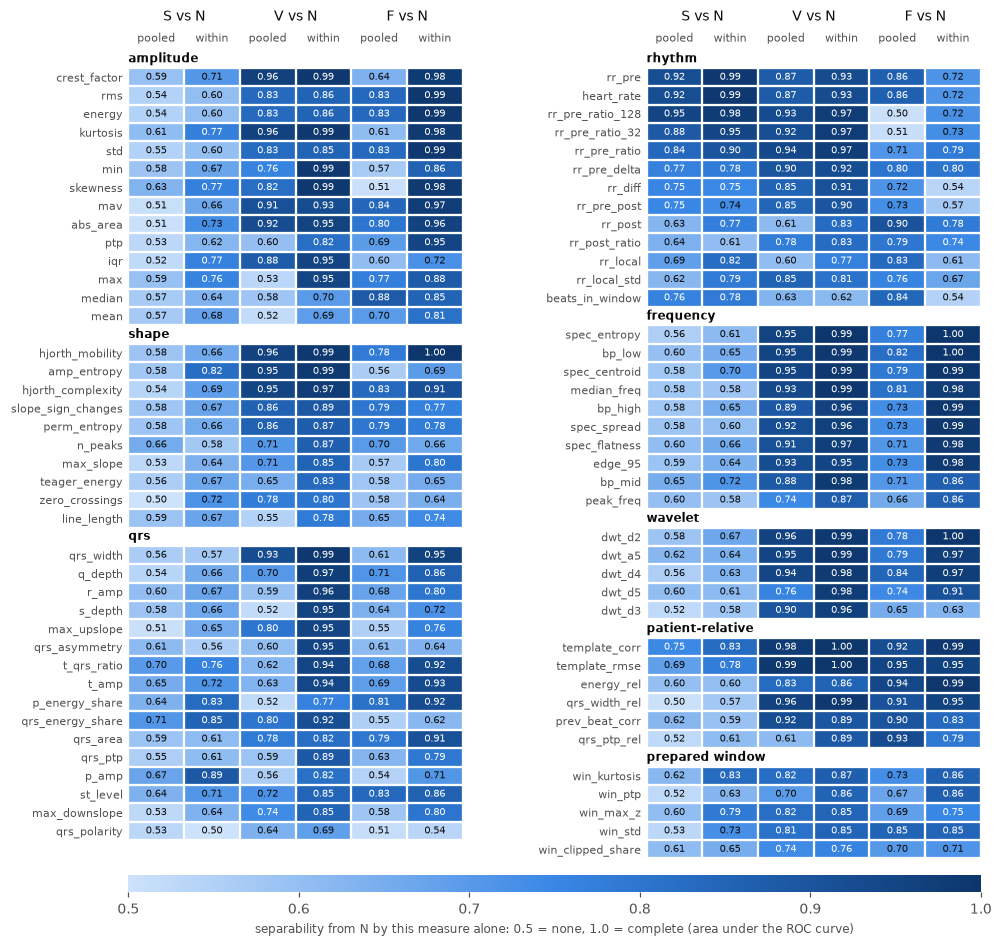

In [23]:
# Separability of all measures, grouped by family (sorted by the best within-record value)
columns = [(c, kind) for c in CLASSES[1:] for kind in ("pooled", "within")]


def family_rows(families):
    out = []
    for family in families:
        d = sep[sep.family == family]
        d = d.assign(best=d[[f"within_{c}" for c in CLASSES[1:]]].max(axis=1)).sort_values("best", ascending=False)
        out += [(family, None)] + [(r.feature, [getattr(r, f"{kind}_{c}") for c, kind in columns]) for r in d.itertuples()]
    return out


blocks = [family_rows(FAMILIES[:3]), family_rows(FAMILIES[3:])]
n_rows = max(len(b) for b in blocks)
fig, axes = plt.subplots(1, 2, figsize=(10, 0.2 * n_rows + 1.2), gridspec_kw={"wspace": 0.55})
for ax, block in zip(axes, blocks):
    grid = np.full((n_rows, len(columns)), np.nan)
    for i, (name, values) in enumerate(block):
        if values is None:
            ax.text(-0.5, i, name, ha="left", va="center", fontsize=8, color=INK, fontweight="bold")
        else:
            grid[i] = values
            for j, v in enumerate(values):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5, color="white" if v >= 0.74 else INK)
    im = ax.imshow(grid, aspect="auto", cmap=SEQ, vmin=0.5, vmax=1.0)
    ax.set_yticks([i for i, (_, values) in enumerate(block) if values is not None],
                  [name for name, values in block if values is not None], fontsize=7)
    ax.set_xticks(range(len(columns)), [kind for _, kind in columns], fontsize=7)
    ax.xaxis.tick_top()
    for j, c in enumerate(CLASSES[1:]):
        ax.text(2 * j + 0.5, -1.9, f"{c} vs N", ha="center", va="bottom", fontsize=9, color=INK)
    ax.set_xticks(np.arange(-0.5, len(columns)), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.grid(which="major", visible=False)
    ax.tick_params(which="both", length=0)
    ax.spines[:].set_visible(False)
cb = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.025, pad=0.02, aspect=50)
cb.set_label("separability from N by this measure alone: 0.5 = none, 1.0 = complete (area under the ROC curve)", fontsize=8)
cb.outline.set_visible(False)
save(fig, "feature_separability")

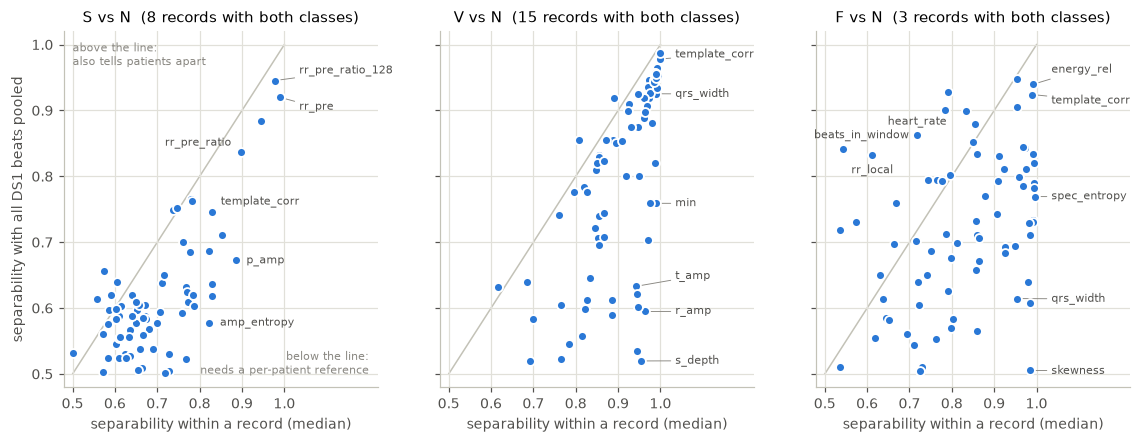

In [24]:
# Within a record versus pooled: on the line a measure works the same way across patients; below it the measure
# separates the classes only relative to the patient; above it the pooled value partly reflects which patients have the class
labels = {  # feature -> y position in the right-hand gutter, or (dx, dy, ha) offset in points
    "S": {"rr_pre_ratio_128": 0.96, "rr_pre": 0.905, "rr_pre_ratio": (-6, 4, "right"), "template_corr": (6, 5, "left"), "p_amp": (7, -2, "left"),
          "amp_entropy": (7, -2, "left")},
    "V": {"template_corr": 0.985, "qrs_width": 0.925, "min": 0.759, "t_amp": 0.648, "r_amp": 0.595, "s_depth": 0.52},
    "F": {"energy_rel": 0.962, "template_corr": 0.915, "spec_entropy": 0.769, "qrs_width": 0.614, "skewness": 0.505,
          "heart_rate": (0, 7, "center"), "beats_in_window": (-19, 7, "left"), "rr_local": (0, -12, "center")},
}
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2), sharex=True, sharey=True)
for ax, c in zip(axes, CLASSES[1:]):
    ax.plot([0.5, 1], [0.5, 1], color="#c3c2b7", lw=1, zorder=1)
    ax.scatter(sep[f"within_{c}"], sep[f"pooled_{c}"], s=34, color=CLASS_COLORS["N"], edgecolor="white", linewidth=1.2, zorder=3)
    for name, where in labels[c].items():
        px, py = sep.loc[sep.feature == name, [f"within_{c}", f"pooled_{c}"]].iloc[0]
        if isinstance(where, tuple):
            ax.annotate(name, (px, py), xytext=where[:2], textcoords="offset points", ha=where[2], fontsize=7, color=INK2)
        else:
            ax.annotate(name, (px, py), xytext=(1.035, where), va="center", fontsize=7, color=INK2, zorder=2,
                        arrowprops={"arrowstyle": "-", "color": MUTED, "lw": 0.6, "shrinkA": 1, "shrinkB": 3})
    ax.set_title(f"{c} vs N  ({int(sep[f'records_{c}'].iloc[0])} records with both classes)")
    ax.set_xlabel("separability within a record (median)")
    ax.set_xlim(0.48, 1.22)
    ax.set_ylim(0.48, 1.02)
    ax.set_xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
axes[0].set_ylabel("separability with all DS1 beats pooled")
axes[0].text(0.5, 1.005, "above the line:\nalso tells patients apart", fontsize=7, color=MUTED, va="top")
axes[0].text(1.2, 0.495, "below the line:\nneeds a per-patient reference", fontsize=7, color=MUTED, ha="right", va="bottom")
save(fig, "feature_within_vs_pooled")

,rr_pre,rr_pre_ratio_128,qrs_width,template_corr,spec_centroid,kurtosis,win_max_z,r_amp
y,,,,,,,,
N,0.76,1.01,30.56,0.99,9.66,11.60,5.27,1.49
S,0.49,0.71,25.00,0.98,12.15,8.92,4.88,1.30
V,0.52,0.73,77.78,0.63,3.84,1.51,3.94,1.26
F,0.59,1.01,33.33,0.86,6.34,7.18,4.48,1.82


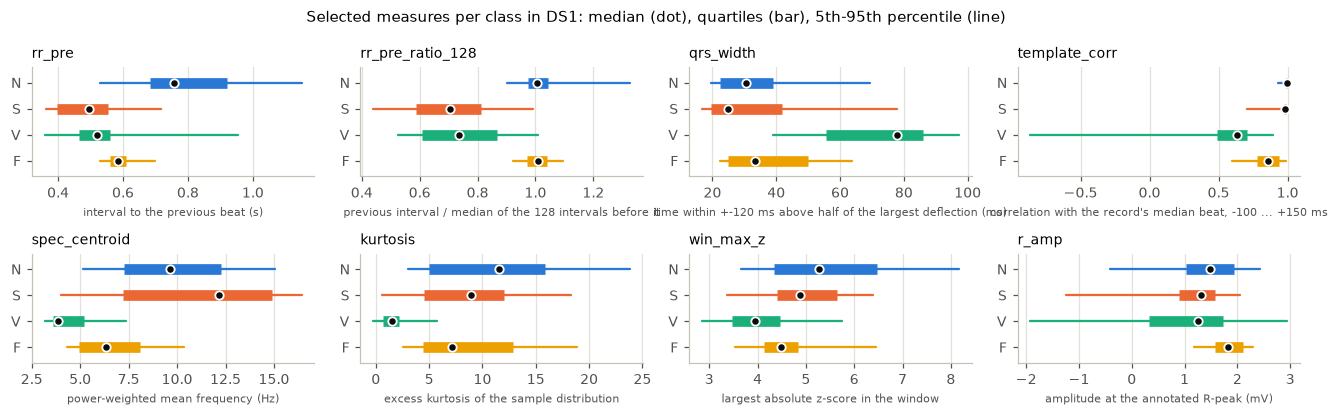

In [25]:
# Distribution per class of one informative measure per family, and of the R-peak amplitude as a counter-example
selected = ["rr_pre", "rr_pre_ratio_128", "qrs_width", "template_corr", "spec_centroid", "kurtosis", "win_max_z", "r_amp"]
fig, axes = plt.subplots(2, 4, figsize=(12, 3.8))
for ax, name in zip(axes.ravel(), selected):
    for i, c in enumerate(CLASSES):
        q = np.nanpercentile(feat.loc[feat.y == i, name], [5, 25, 50, 75, 95])
        row = len(CLASSES) - 1 - i
        ax.plot(q[[0, 4]], [row, row], color=CLASS_COLORS[c], lw=1.5, solid_capstyle="round")
        ax.plot(q[[1, 3]], [row, row], color=CLASS_COLORS[c], lw=7, solid_capstyle="butt")
        ax.scatter(q[2], row, s=30, color=INK, edgecolor="white", linewidth=1.2, zorder=3)
    ax.set_yticks(range(len(CLASSES)), CLASSES[::-1])
    ax.set_ylim(-0.6, len(CLASSES) - 0.4)
    ax.grid(axis="y", visible=False)
    ax.set_title(name, loc="left", fontsize=9)
    ax.set_xlabel(FEATURES[name][1], fontsize=7)
fig.suptitle("Selected measures per class in DS1: median (dot), quartiles (bar), 5th-95th percentile (line)", fontsize=10)
fig.tight_layout()
save(fig, "feature_distributions")
feat.groupby(feat.y.map(dict(enumerate(CLASSES))))[selected].median().reindex(CLASSES).round(2)

Pairs with absolute rank correlation above 0.9: 73 of 3081; 54 measures remain after dropping one of each such pair
Most redundant pairs: [('std', 'rms', 0.999), ('std', 'energy', 0.999), ('rms', 'energy', 1.0), ('slope_sign_changes', 'perm_entropy', 0.994), ('hjorth_mobility', 'spec_centroid', 0.988), ('hjorth_mobility', 'dwt_d2', 1.0), ('rr_pre', 'heart_rate', 1.0), ('rr_pre_post', 'rr_diff', 0.996), ('spec_centroid', 'spec_entropy', 0.986), ('spec_centroid', 'dwt_d2', 0.989)]


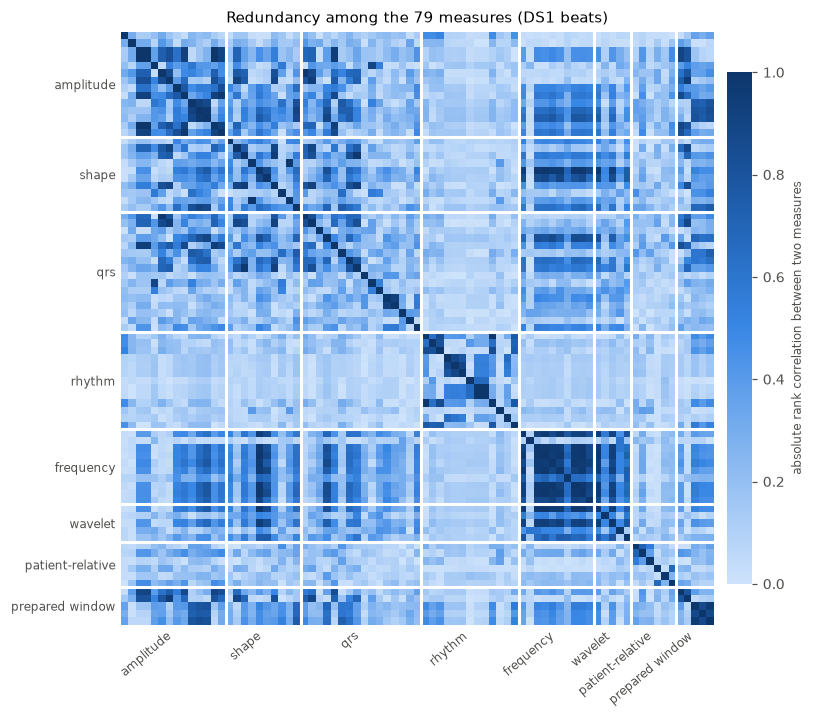

In [26]:
# Redundancy: absolute rank correlation between all pairs of measures
names = list(FEATURES)
R = np.abs(feat[names].rank().corr().to_numpy())
edges = np.cumsum([sum(family == f for family, _ in FEATURES.values()) for f in FAMILIES])
starts = np.r_[0, edges[:-1]]
fig, ax = plt.subplots(figsize=(7.5, 7))
im = ax.imshow(R, cmap=SEQ, vmin=0, vmax=1)
for e in edges[:-1]:
    ax.axhline(e - 0.5, color="white", lw=2)
    ax.axvline(e - 0.5, color="white", lw=2)
ax.set_xticks((starts + edges) / 2 - 0.5, FAMILIES, rotation=40, ha="right", fontsize=8)
ax.set_yticks((starts + edges) / 2 - 0.5, FAMILIES, fontsize=8)
ax.grid(False)
ax.tick_params(length=0)
ax.spines[:].set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cb.set_label("absolute rank correlation between two measures", fontsize=8)
cb.outline.set_visible(False)
ax.set_title(f"Redundancy among the {len(names)} measures (DS1 beats)")
save(fig, "feature_correlation")

upper = np.triu_indices(len(names), 1)
kept = []  # greedy: go through the measures from most to least separating, keep those not above 0.9 with a kept one
for i in np.argsort(-sep[[f"within_{c}" for c in CLASSES[1:]]].max(axis=1).to_numpy()):
    if all(R[i, j] <= 0.9 for j in kept):
        kept.append(i)
print(f"Pairs with absolute rank correlation above 0.9: {(R[upper] > 0.9).sum()} of {len(upper[0])}; "
      f"{len(kept)} measures remain after dropping one of each such pair")
print("Most redundant pairs:", [(names[i], names[j], round(float(R[i, j]), 3)) for i, j in zip(*upper) if R[i, j] > 0.985])

## 2.4 Data quality

In [27]:
# Missing data, flat-line segments, ADC saturation and artifact/quality annotations for every DS1 record.
rows = []
for r in DS1:
    rec = wfdb.rdrecord(str(MITDB / str(r)), physical=False)
    ch = rec.sig_name.index(LEAD)
    d = rec.d_signal[:, ch]
    x = rec.p_signal[:, ch] if rec.p_signal is not None else (d - rec.baseline[ch]) / rec.adc_gain[ch]
    blocks = x[: len(x) // FS * FS].reshape(-1, FS)
    ann = wfdb.rdann(str(MITDB / str(r)), "atr")
    sym = np.array(ann.symbol)
    rows.append({
        "record": r, "split": record_stats.set_index("record").split[r],
        "nan_samples": int(np.isnan(x).sum()),
        "flat_seconds": int((blocks.std(axis=1) < 0.01).sum()),
        "saturated_samples": int(((d <= d.min()) | (d >= d.max())).sum()) if d.max() - d.min() >= 2 ** rec.adc_res[ch] - 2 else 0,
        "adc_min": int(d.min()), "adc_max": int(d.max()),
        "artifact_marks_|": int((sym == "|").sum()), "quality_changes_~": int((sym == "~").sum()),
        "excluded_beats": int(record_stats.set_index("record").excluded_beats[r]),
    })
quality_df = pd.DataFrame(rows)
quality_df.to_csv(STATS / "data_quality.csv", index=False)
print("Total NaN samples:", quality_df.nan_samples.sum(), "| records with flat seconds:",
      int((quality_df.flat_seconds > 0).sum()), "| records touching ADC limits:", int((quality_df.saturated_samples > 0).sum()))
quality_df

Total NaN samples: 0 | records with flat seconds: 0 | records touching ADC limits: 1


,record,split,nan_samples,flat_seconds,saturated_samples,adc_min,adc_max,artifact_marks_|,quality_changes_~,excluded_beats
0,101,train,0,0,0,389,1508,4,4,2
1,106,train,0,0,0,611,1538,0,30,0
2,108,train,0,0,0,417,1497,8,41,0
3,109,val,0,0,0,385,1650,0,2,0
4,112,train,0,0,0,497,1188,0,10,0
5,114,train,0,0,0,523,1778,1,7,0
6,115,train,0,0,0,447,1506,6,2,0
7,116,train,0,0,928,0,2047,0,8,0
8,118,train,0,0,0,406,1503,0,12,0
9,119,train,0,0,0,427,1524,0,4,0


MLII marked noisy: 620 s (1.56% of DS1), 886 beats (1.74%); marked unreadable: 5.3 s, 0 beats
Beat windows containing a saturated sample: 10; containing an isolated artifact mark: 115 (0.23%)
Stretches of more than 3 s without a beat annotation: 9 with 163 s in total; per record: {201: 7.5, 207: 152.1, 208: 3.1}
Records whose N class is not made of 'N' beats: {109: 'L:2490', 118: 'R:2165', 124: 'R:1529 j:5', 207: 'L:1457 R:85'}
Peak-to-peak range of the beat window (filtered, mV): median over all beats 2.20, largest 6.24; windows above 5 mV: 64 in records {116: 40, 203: 13, 109: 10, 114: 1}
Record 116: 928 saturated samples in 8 runs, 3 episodes at [1002, 1391, 1404] s, longest run 0.74 s


,record,saturated_runs,windows_with_saturation,noisy_seconds,unreadable_seconds,beats_in_noisy,beats_in_unreadable,windows_with_artifact,annotation_gaps_over_3s,gap_seconds,n_class_symbols
2,108,0,0,196.1,0.0,207,0,12,0,0.0,N:1738 j:1
4,112,0,0,21.0,0.0,30,0,0,0,0.0,N:2535
7,116,8,10,25.0,0.0,34,0,0,0,0.0,N:2300
8,118,0,0,24.4,0.0,31,0,0,0,0.0,R:2165
12,201,0,0,4.5,0.0,4,0,0,2,7.5,N:1624 j:10
13,203,0,0,226.9,1.6,389,0,48,0,0.0,N:2528
15,207,0,0,41.3,0.0,55,0,2,6,152.1,L:1457 R:85
16,208,0,0,62.5,2.7,105,0,19,1,3.1,N:1585
17,209,0,0,0.0,0.0,0,0,13,0,0.0,N:2619


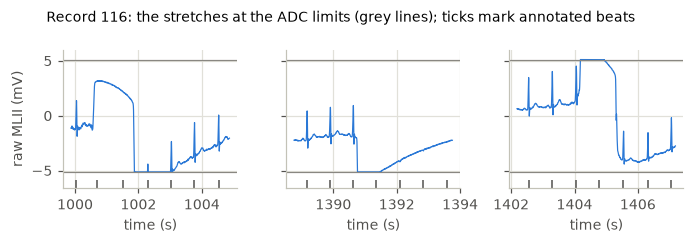

In [28]:
# Corrupted and noisy stretches per DS1 record, and how many beat windows they touch.
# Signal-quality annotations ('~'): the flag holds until the next '~' (same convention as above).
POST = cfg["window"]["post_samples"]
rows, saturation_runs = [], {}
for r, (x, xf, samples, symbols) in filtered_ds1.items():
    rec = wfdb.rdrecord(str(MITDB / str(r)), physical=False)
    ch = rec.sig_name.index(LEAD)
    d, n = rec.d_signal[:, ch], rec.sig_len
    subtype = np.asarray(wfdb.rdann(str(MITDB / str(r)), "atr").subtype)
    keep = np.array([sym in MAP for sym in symbols]) & (samples - PRE >= 0) & (samples + POST <= n)
    beats = samples[keep]

    def windows_touching(mask):  # beat windows that contain at least one flagged sample
        c = np.concatenate([[0], np.cumsum(mask)])
        return int(((c[beats + POST] - c[beats - PRE]) > 0).sum())

    saturated = (d <= 0) | (d >= 2 ** rec.adc_res[ch] - 1)
    edges = np.flatnonzero(np.diff(np.concatenate([[0], saturated.astype(int), [0]])))
    saturation_runs[r] = list(zip(edges[::2], edges[1::2]))
    flag = np.zeros(n, dtype=np.int8)  # 1 = MLII marked noisy, 2 = MLII marked unreadable
    marks = np.flatnonzero(symbols == "~")
    for k, i in enumerate(marks):
        sub, end = int(subtype[i]), samples[marks[k + 1]] if k + 1 < len(marks) else n
        if sub == -1 or (sub > 0 and sub & (1 << (ch + 4))):
            flag[samples[i]:end] = 2
        elif sub > 0 and sub & (1 << ch):
            flag[samples[i]:end] = 1
    artifact = np.zeros(n, dtype=bool)
    artifact[samples[symbols == "|"]] = True
    gaps = np.diff(np.sort(samples[np.isin(symbols, cfg["qrs_symbols"])])) / FS
    n_class = pd.Series(symbols[keep]).value_counts()
    rows.append({
        "record": r, "saturated_runs": len(saturation_runs[r]), "windows_with_saturation": windows_touching(saturated),
        "noisy_seconds": round((flag == 1).sum() / FS, 1), "unreadable_seconds": round((flag == 2).sum() / FS, 1),
        "beats_in_noisy": int((flag[beats] == 1).sum()), "beats_in_unreadable": int((flag[beats] == 2).sum()),
        "windows_with_artifact": windows_touching(artifact),
        "annotation_gaps_over_3s": int((gaps > 3).sum()), "gap_seconds": round(float(gaps[gaps > 3].sum()), 1),
        "n_class_symbols": " ".join(f"{sym}:{k}" for sym, k in n_class.items() if sym in cfg["labels"]["N"]),
    })
detail = pd.DataFrame(rows)
quality_df = quality_df.merge(detail, on="record")
quality_df.to_csv(STATS / "data_quality.csv", index=False)

total_beats, total_seconds = len(feat), sum(len(x) for x, *_ in filtered_ds1.values()) / FS
print(f"MLII marked noisy: {detail.noisy_seconds.sum():.0f} s ({detail.noisy_seconds.sum() / total_seconds:.2%} of DS1), "
      f"{detail.beats_in_noisy.sum()} beats ({detail.beats_in_noisy.sum() / total_beats:.2%}); "
      f"marked unreadable: {detail.unreadable_seconds.sum():.1f} s, {detail.beats_in_unreadable.sum()} beats")
print(f"Beat windows containing a saturated sample: {detail.windows_with_saturation.sum()}; "
      f"containing an isolated artifact mark: {detail.windows_with_artifact.sum()} ({detail.windows_with_artifact.sum() / total_beats:.2%})")
print(f"Stretches of more than 3 s without a beat annotation: {detail.annotation_gaps_over_3s.sum()} with {detail.gap_seconds.sum():.0f} s in total; "
      f"per record: {detail[detail.gap_seconds > 0].set_index('record').gap_seconds.to_dict()}")
print("Records whose N class is not made of 'N' beats:",
      detail[~detail.n_class_symbols.str.startswith("N:")].set_index("record").n_class_symbols.to_dict())
wide = feat.groupby("record").win_ptp.agg(["median", "max"]).round(2)
print(f"Peak-to-peak range of the beat window (filtered, mV): median over all beats {feat.win_ptp.median():.2f}, largest {feat.win_ptp.max():.2f}; "
      f"windows above 5 mV: {(feat.win_ptp > 5).sum()} in records {feat[feat.win_ptp > 5].record.value_counts().to_dict()}")

# The saturated stretches of the only record that reaches the ADC limits
r = max(saturation_runs, key=lambda k: len(saturation_runs[k]))
x, _, samples, symbols = filtered_ds1[r]
starts = np.array([a for a, _ in saturation_runs[r]])
episodes = [starts[0]] + [s for prev, s in zip(starts[:-1], starts[1:]) if s - prev > 5 * FS]
fig, axes = plt.subplots(1, len(episodes), figsize=(6.5, 2.2), sharey=True)
for ax, start in zip(np.atleast_1d(axes), episodes):
    seg = slice(start - 2 * FS, start + 3 * FS)
    ax.plot(np.arange(seg.start, seg.stop) / FS, x[seg], color=CLASS_COLORS["N"], lw=0.8)
    for limit in (-5.12, 5.115):
        ax.axhline(limit, color=MUTED, lw=0.8)
    beats_here = samples[(samples >= seg.start) & (samples < seg.stop) & np.isin(symbols, list(MAP))]
    ax.plot(beats_here / FS, np.full(len(beats_here), -6.2), "|", color=INK2, ms=5)
    ax.set_xlabel("time (s)")
    ax.set_ylim(-6.6, 6)
np.atleast_1d(axes)[0].set_ylabel(f"raw {LEAD} (mV)")
fig.suptitle(f"Record {r}: the stretches at the ADC limits (grey lines); ticks mark annotated beats", fontsize=9)
fig.tight_layout()
save(fig, f"saturation_{r}")
print(f"Record {r}: {sum(b - a for a, b in saturation_runs[r])} saturated samples in {len(saturation_runs[r])} runs, "
      f"{len(episodes)} episodes at {[round(s / FS) for s in episodes]} s, longest run {max(b - a for a, b in saturation_runs[r]) / FS:.2f} s")
detail[(detail.noisy_seconds > 20) | (detail.windows_with_artifact > 10) | (detail.gap_seconds > 0) | (detail.saturated_runs > 0)]

In [29]:
# Consistency of the recording parameters of MLII across the DS1 records
params = set()
for r in DS1:
    h = wfdb.rdheader(str(MITDB / str(r)))
    ch = h.sig_name.index(LEAD)
    params.add((h.fs, h.sig_len, h.adc_gain[ch], h.adc_res[ch], h.units[ch]))
print("Distinct (sampling frequency, samples, ADC units per mV, ADC bits, unit) among the DS1 records:", params)

Distinct (sampling frequency, samples, ADC units per mV, ADC bits, unit) among the DS1 records: {(360, 650000, 200.0, 11, 'mV')}


,record,baseline_wander_ratio,high_freq_ratio
2,108,1.9376,0.0096
17,209,0.2534,0.0094
0,101,0.2813,0.0075
19,220,0.0366,0.0072
18,215,0.0566,0.0058
1,106,0.0710,0.0048
14,205,0.1154,0.0042
6,115,0.3911,0.0040


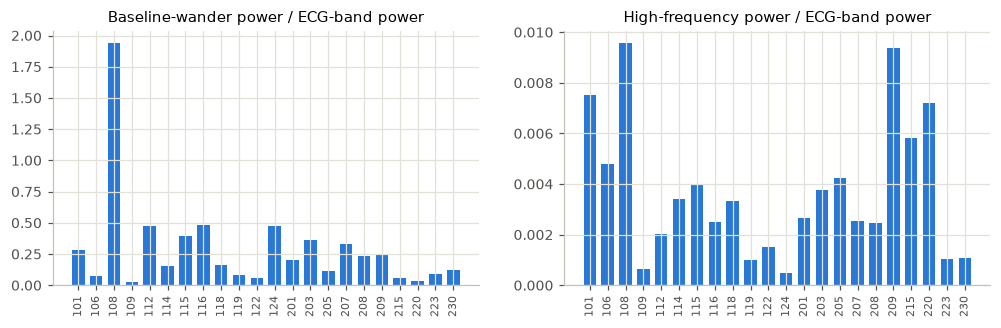

In [30]:
# Noise-level proxies per DS1 record: baseline-wander (<0.5 Hz) and high-frequency (>40 Hz) power relative to ECG band power
rows = []
lo = sps.butter(4, 0.5, btype="lowpass", fs=FS, output="sos")
hi = sps.butter(4, 40.0, btype="highpass", fs=FS, output="sos")
for r, (x, xf, _, _) in filtered_ds1.items():
    rows.append({
        "record": r,
        "baseline_wander_ratio": sps.sosfiltfilt(lo, x - x.mean()).var() / xf.var(),
        "high_freq_ratio": sps.sosfiltfilt(hi, x).var() / xf.var(),
    })
noise_proxy = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharex=True)
xs = np.arange(len(noise_proxy))
for ax, col, title in zip(axes, ["baseline_wander_ratio", "high_freq_ratio"],
                          ["Baseline-wander power / ECG-band power", "High-frequency power / ECG-band power"]):
    ax.bar(xs, noise_proxy[col], color=CLASS_COLORS["N"], width=0.7)
    ax.set_xticks(xs, noise_proxy.record, rotation=90, fontsize=7)
    ax.set_title(title)
save(fig, "noise_proxies_ds1")
noise_proxy.round(4).sort_values("high_freq_ratio", ascending=False).head(8)

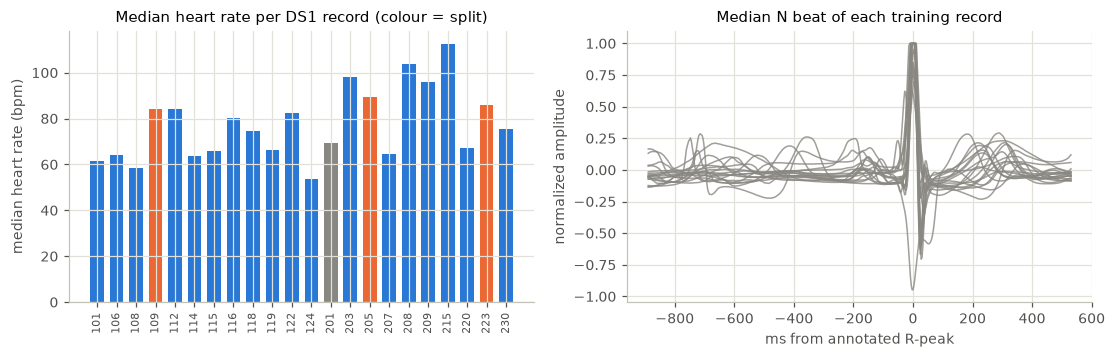

In [31]:
# Differences between recordings: heart rate and normal-beat morphology (DS1 records only)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
rs = record_stats[record_stats.record.isin(DS1)].sort_values("record")
xs = np.arange(len(rs))
axes[0].bar(xs, 60 / rs.median_rr_s, color=[SPLIT_COLORS[s] for s in rs.split], width=0.7)
axes[0].set_xticks(xs, rs.record, rotation=90, fontsize=7)
axes[0].set_ylabel("median heart rate (bpm)")
axes[0].set_title("Median heart rate per DS1 record (colour = split)")

for r in SPLITS["train"]:
    idx = np.flatnonzero((train["record"] == r) & (train["y"] == 0))
    if len(idx) > 50:
        axes[1].plot(t_ms, np.median(X[idx], axis=0), lw=1, alpha=0.8, color=MUTED)
axes[1].set_xlabel("ms from annotated R-peak")
axes[1].set_ylabel("normalized amplitude")
axes[1].set_title("Median N beat of each training record")
save(fig, "record_differences")

Channel pairs: {'MLII / V1': 38, 'MLII / V5': 2, 'MLII / V2': 2, 'V5 / MLII': 1, 'MLII / V4': 1}
Records where MLII is not channel 0: [114]


QRS peak-to-peak amplitude (first 300 normal beats): MLII larger than the other channel in 21 of 22 DS1 records; median 2.02 mV against 0.86 mV; exceptions: [108]
Second lead in DS1: {'V1': 20, 'V5': 1, 'V4': 1} | in all used records: {'V1': 38, 'V5': 3, 'V2': 2, 'V4': 1}
Database records without MLII: [102, 104]


,record,leads,correlation,qrs_ptp_MLII_mV,qrs_ptp_other_mV
0,101,MLII / V1,-0.338,1.727,0.165
1,106,MLII / V1,0.141,2.071,0.432
2,108,MLII / V1,-0.356,0.912,1.494
3,109,MLII / V1,-0.792,2.232,1.305
4,112,MLII / V1,-0.271,1.162,0.466
5,114,V5 / MLII,0.139,2.098,0.624
6,115,MLII / V1,-0.158,3.061,0.519
7,116,MLII / V1,-0.628,4.125,0.868
8,118,MLII / V1,0.090,2.743,2.201
9,119,MLII / V1,-0.829,2.375,1.222


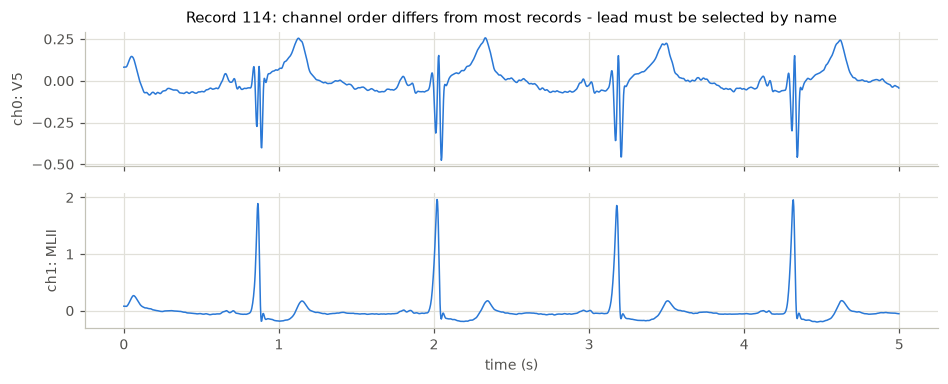

In [32]:
# Differences between ECG channels
print("Channel pairs:", (headers.channel_0 + " / " + headers.channel_1).value_counts().to_dict())
print("Records where MLII is not channel 0:", headers.loc[headers.channel_0 != LEAD, "record"].tolist())

r = 114  # DS1 record with MLII on channel 1
rec = wfdb.rdrecord(str(MITDB / str(r)))
seg = slice(0, 5 * FS)
t = np.arange(seg.stop) / FS
fig, axes = plt.subplots(2, 1, figsize=(10, 3.5), sharex=True)
for ax, ch in zip(axes, range(rec.n_sig)):
    ax.plot(t, preprocess_signal(rec.p_signal[:, ch], FS, cfg)[seg], color=CLASS_COLORS["N"], lw=1)
    ax.set_ylabel(f"ch{ch}: {rec.sig_name[ch]}")
axes[0].set_title(f"Record {r}: channel order differs from most records - lead must be selected by name")
axes[1].set_xlabel("time (s)")
save(fig, "channel_differences")

corr = []
for r in DS1:
    rec = wfdb.rdrecord(str(MITDB / str(r)))
    a, b = (preprocess_signal(rec.p_signal[:, i], FS, cfg) for i in range(2))
    samples, symbols = filtered_ds1[r][2:]
    ptp = {name: np.sqrt(8 * qrs_power(rec.p_signal[:, i], FS, samples, symbols)) for i, name in enumerate(rec.sig_name)}
    other = next(name for name in rec.sig_name if name != LEAD)
    corr.append({"record": r, "leads": " / ".join(rec.sig_name), "correlation": np.corrcoef(a, b)[0, 1],
                 f"qrs_ptp_{LEAD}_mV": ptp[LEAD], "qrs_ptp_other_mV": ptp[other]})
channels = pd.DataFrame(corr)
larger = channels[f"qrs_ptp_{LEAD}_mV"] > channels.qrs_ptp_other_mV
print(f"QRS peak-to-peak amplitude (first 300 normal beats): {LEAD} larger than the other channel in {larger.sum()} of {len(channels)} "
      f"DS1 records; median {channels[f'qrs_ptp_{LEAD}_mV'].median():.2f} mV against {channels.qrs_ptp_other_mV.median():.2f} mV; "
      f"exceptions: {channels.loc[~larger, 'record'].tolist()}")
print("Second lead in DS1:", channels.leads.str.replace(LEAD, "").str.strip(" /").value_counts().to_dict(),
      "| in all used records:", pd.concat([headers.channel_0, headers.channel_1]).loc[lambda s: s != LEAD].value_counts().to_dict())
print("Database records without", LEAD + ":", [int(p.stem) for p in sorted(MITDB.glob("*.hea")) if p.stem.isdigit()
                                                and LEAD not in wfdb.rdheader(str(p.with_suffix(""))).sig_name])
channels.round(3)

## 2.5 Leakage analysis

Checks below are the programmatic part; the argument itself belongs in the report.

In [33]:
ds1, ds2 = set(cfg["splits"]["ds1"]), set(cfg["splits"]["ds2"])
print("DS1 and DS2 share records:", sorted(ds1 & ds2) or "none")
print("Train and validation share records:", sorted(set(SPLITS["train"]) & set(SPLITS["val"])) or "none")
print("Records per split:", {k: len(v) for k, v in SPLITS.items()})
print("DS1 records excluded from training and validation:", SPLITS["excluded"])

# Records 201 and 202 come from the same subject (PhysioNet MIT-BIH directory) -> same person in DS1 and DS2.
for r in (201, 202):
    print(r, "in", "DS1" if r in ds1 else "DS2", "| header comment:", wfdb.rdheader(str(MITDB / str(r))).comments)

DS1 and DS2 share records: none
Train and validation share records: none
Records per split: {'train': 18, 'val': 3, 'excluded': 1, 'test': 22}
DS1 records excluded from training and validation: [201]
201 in DS1 | header comment: ['68 M 1960 2851 x1', 'Digoxin, Hydrochlorthiazide, Inderal, KCl', 'The PVCs are uniform and late-cycle.  Junctional escape beats occur following', 'episodes of ventricular trigeminy.']
202 in DS2 | header comment: ['68 M 1960 2851 x1', 'Digoxin, Hydrochlorthiazide, Inderal, KCl', 'The PVCs are uniform and late-cycle.  This record was taken from the same', 'analog tape as record 201.']


Windows sharing samples with the window of the next beat: 99.5%; median shared part: 48% of the window (246 samples)
ECG samples that lie in a beat window: 73% of them lie in two or more windows



The most similar other beat comes from the same record for 98.3% of the beats (median distance in time 185 s)
Using the label of the most similar beat: macro F1 0.910 with any other beat, 0.452 with beats of other records only


,"same label, any other beat","same label, other records only","F1, any other beat","F1, other records only"
N,0.996,0.939,0.995,0.950
S,0.828,0.230,0.864,0.157
V,0.965,0.723,0.969,0.683
F,0.802,0.012,0.812,0.017


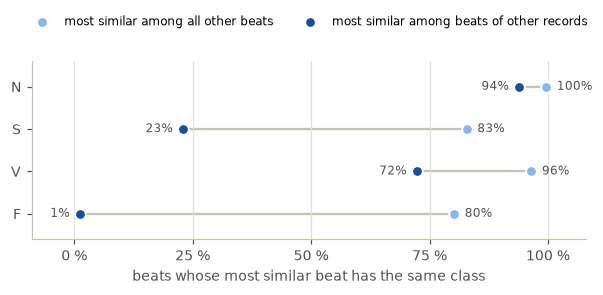

In [34]:
# What beat windows of the same record have in common (DS1 only).
# 1. Shared samples: the window (512 samples) is longer than most RR intervals, so consecutive windows overlap.
POST = cfg["window"]["post_samples"]
LENGTH = PRE + POST
overlap = (LENGTH - feat.rr_post * FS).clip(lower=0) / LENGTH  # part of a window shared with the next beat's window
print(f"Windows sharing samples with the window of the next beat: {(overlap > 0).mean():.1%}; "
      f"median shared part: {overlap.median():.0%} of the window ({overlap.median() * LENGTH:.0f} samples)")
covered = repeated = 0
for r, (x, _, _, _) in filtered_ds1.items():
    beats = feat.loc[feat.record == r, "sample"].to_numpy()
    steps = np.zeros(len(x) + 1, dtype=int)
    np.add.at(steps, beats - PRE, 1)
    np.add.at(steps, beats + POST, -1)
    count = np.cumsum(steps[:-1])
    covered, repeated = covered + (count > 0).sum(), repeated + (count > 1).sum()
print(f"ECG samples that lie in a beat window: {repeated / covered:.0%} of them lie in two or more windows")

# 2. Similar beats: for every beat, the most similar other beat (Euclidean distance between the prepared windows),
#    searched among all other DS1 beats and among the beats of other records only.
ds1_sets = [np.load(resolve(cfg["paths"]["processed_dir"]) / f"{name}.npz")
            for name in ("train", "val", "excluded") if SPLITS[name]]  # all 22 DS1 records
Xa = np.concatenate([d["X"][:, 0] for d in ds1_sets]).astype(np.float32)
ya, ra, sa = (np.concatenate([d[key] for d in ds1_sets]) for key in ("y", "record", "sample"))
squares = (Xa ** 2).sum(axis=1)
nn_any, nn_other = np.empty(len(ya), dtype=int), np.empty(len(ya), dtype=int)
for start in range(0, len(ya), 2000):
    rows = np.arange(start, min(start + 2000, len(ya)))
    d2 = squares[rows, None] + squares[None, :] - 2 * Xa[rows] @ Xa.T
    d2[np.arange(len(rows)), rows] = np.inf            # not the beat itself
    nn_any[rows] = d2.argmin(axis=1)
    d2[ra[rows, None] == ra[None, :]] = np.inf           # not a beat of the same record
    nn_other[rows] = d2.argmin(axis=1)


def lookup_scores(neighbour):
    """Per class: share of beats whose neighbour has the same label, and the F1 of using the neighbour's label."""
    cm = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)
    np.add.at(cm, (ya, ya[neighbour]), 1)
    recall = cm.diagonal() / cm.sum(axis=1)
    precision = cm.diagonal() / np.maximum(cm.sum(axis=0), 1)
    return recall, 2 * precision * recall / np.maximum(precision + recall, 1e-12)


same = ra[nn_any] == ra
print(f"\nThe most similar other beat comes from the same record for {same.mean():.1%} of the beats "
      f"(median distance in time {np.median(np.abs(sa[nn_any] - sa)[same]) / FS:.0f} s)")
(recall_any, f1_any), (recall_other, f1_other) = lookup_scores(nn_any), lookup_scores(nn_other)
lookup = pd.DataFrame({"same label, any other beat": recall_any, "same label, other records only": recall_other,
                       "F1, any other beat": f1_any, "F1, other records only": f1_other}, index=CLASSES)
print(f"Using the label of the most similar beat: macro F1 {f1_any.mean():.3f} with any other beat, "
      f"{f1_other.mean():.3f} with beats of other records only")

fig, ax = plt.subplots(figsize=(6.5, 2.1))
LIGHT, DARK = "#86b6ef", "#184f95"
for i, c in enumerate(CLASSES):
    row = len(CLASSES) - 1 - i
    ax.plot([recall_other[i], recall_any[i]], [row, row], color="#c3c2b7", lw=1.5, zorder=1)
    ax.scatter(recall_any[i], row, s=48, color=LIGHT, edgecolor="white", linewidth=1.2, zorder=3,
               label="most similar among all other beats" if i == 0 else None)
    ax.scatter(recall_other[i], row, s=48, color=DARK, edgecolor="white", linewidth=1.2, zorder=3,
               label="most similar among beats of other records" if i == 0 else None)
    ax.annotate(f"{recall_any[i]:.0%}", (recall_any[i], row), xytext=(7, 0), textcoords="offset points", va="center", fontsize=8, color=INK2)
    ax.annotate(f"{recall_other[i]:.0%}", (recall_other[i], row), xytext=(-7, 0), textcoords="offset points", va="center", ha="right", fontsize=8, color=INK2)
ax.set_yticks(range(len(CLASSES)), CLASSES[::-1])
ax.set_ylim(-0.6, len(CLASSES) - 0.4)
ax.set_xlim(-0.09, 1.08)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0], ["0 %", "25 %", "50 %", "75 %", "100 %"])
ax.grid(axis="y", visible=False)
ax.set_xlabel("beats whose most similar beat has the same class")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.32), ncols=2, fontsize=8)
save(fig, "leakage_nearest_beat")
lookup.round(3)

## Evidence for the data preparation (report section 3)

Checks on DS1 that support, or question, the parameters of `configs/data.yaml`. They describe the data; which
parameter values are best is decided by cross-validation in the modelling stage.

,N,S,V,F
samples before,,,,
64,0.000,0.000,0.000,0.000
192,0.055,0.669,0.593,0.060
320,0.703,0.965,0.923,0.971
448,0.975,1.000,0.998,0.995


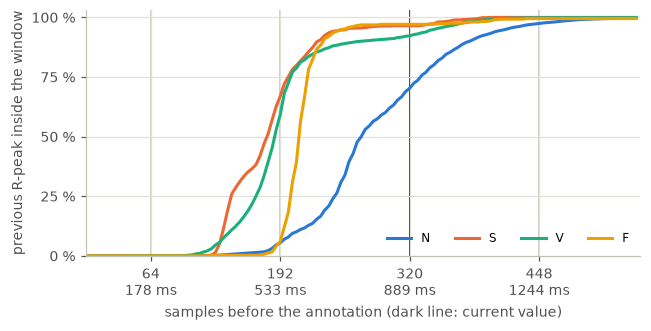

In [35]:
# Window before the beat: share of beats whose previous R-peak lies inside the window, by window length
candidates = [64, 192, 320, 448]  # samples before the annotation; PRE is the current value
grid = np.arange(0, 545, 4)
fig, ax = plt.subplots(figsize=(6.5, 2.9))
for i, c in enumerate(CLASSES):
    rr = feat.loc[feat.y == i, "rr_pre"].dropna().to_numpy() * FS
    share = [(rr < g).mean() for g in grid]
    ax.plot(grid, share, color=CLASS_COLORS[c], lw=2, label=c)
for pre in candidates:
    ax.axvline(pre, color=INK if pre == PRE else "#c3c2b7", lw=1, zorder=1)
ax.set_xticks(candidates, [f"{pre}\n{pre / FS * 1000:.0f} ms" for pre in candidates])
ax.set_xlim(0, 548)
ax.set_ylim(0, 1.03)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0], ["0 %", "25 %", "50 %", "75 %", "100 %"])
ax.set_xlabel("samples before the annotation (dark line: current value)")
ax.set_ylabel("previous R-peak inside the window")
ax.legend(loc="lower right", ncols=4, fontsize=8)
save(fig, "window_coverage")
coverage = pd.DataFrame({c: [(feat.loc[feat.y == i, "rr_pre"] * FS < pre).mean() for pre in candidates]
                         for i, c in enumerate(CLASSES)}, index=pd.Index(candidates, name="samples before"))
coverage.round(3)

In [36]:
# Preprocessing steps (report section 3.4)
bp, clip = cfg["signal"]["bandpass"], cfg["normalization"]["clip"]
POST = cfg["window"]["post_samples"]
dev = record_stats[record_stats.split != "test"]

# 1. Band-pass: effect on the QRS complex, and distance of the high-pass edge from the slowest rhythm
ratio = [np.sqrt(qrs_power(xf, FS, samples, symbols) / qrs_power(x, FS, samples, symbols))
         for x, xf, samples, symbols in filtered_ds1.values()]
print(f"1. QRS peak-to-peak amplitude after the band-pass relative to before: median {np.median(ratio):.2f} "
      f"(range {min(ratio):.2f}-{max(ratio):.2f} over the DS1 records)")
print(f"   Slowest median heart rate in DS1: {60 / dev.median_rr_s.max():.0f} bpm = {1 / dev.median_rr_s.max():.2f} Hz; "
      f"high-pass edge {bp['low_hz']} Hz")

# 2. Order: filtering each window on its own instead of the whole record
sos = sps.butter(bp["order"], [bp["low_hz"], bp["high_hz"]], btype="bandpass", fs=FS, output="sos")
rng, deviation = np.random.default_rng(cfg["seed"]), []
for r, (x, xf, _, _) in filtered_ds1.items():
    beats = rng.choice(feat.loc[feat.record == r, "sample"].to_numpy(), 200, replace=False)
    idx = beats[:, None] + np.arange(-PRE, POST)[None, :]
    alone = sps.sosfiltfilt(sos, x[idx], axis=1)
    deviation.append(np.sqrt(((alone - xf[idx]) ** 2).mean(axis=1)) / xf[idx].std(axis=1))
deviation = np.concatenate(deviation)
print(f"2. Filtering each window on its own: RMS deviation from the whole-record result, in units of the window's "
      f"standard deviation: median {np.median(deviation):.2f}, 95th percentile {np.percentile(deviation, 95):.2f}")

# 3. Per-window z-score: the divisor depends on how many beats the window holds (N beats only)
normal = feat[feat.y == 0]
by_beats = normal.groupby(normal.beats_in_window.clip(upper=3).astype(int))[["win_std", "win_max_z"]].median()
print("3. N beats, by number of annotated beats in the window (3 = three or more): median window standard deviation (mV) "
      f"{by_beats.win_std.round(3).to_dict()}, median largest z-score {by_beats.win_max_z.round(2).to_dict()}")
print(f"   Window standard deviation over all DS1 beats: 5th-95th percentile {feat.win_std.quantile(0.05):.2f}-{feat.win_std.quantile(0.95):.2f} mV")

# 4. Clip level: windows that lose a peak, and the size of one 8-bit step
levels = [4, 5, 6, 8, 10]
clip_table = pd.DataFrame({"all": [(feat.win_max_z > c).mean() for c in levels],
                           **{cls: [(feat.loc[feat.y == i, "win_max_z"] > c).mean() for c in levels] for i, cls in enumerate(CLASSES)},
                           "8-bit step (std)": [c / 128 for c in levels]}, index=pd.Index(levels, name="clip level"))
print(f"4. Largest z-score in a window: median {feat.win_max_z.median():.2f}, 99th percentile {feat.win_max_z.quantile(0.99):.2f}, "
      f"maximum {feat.win_max_z.max():.2f}; current clip level {clip:g}. Share of windows with at least one clipped sample:")
clip_table.round(3)

1. QRS peak-to-peak amplitude after the band-pass relative to before: median 0.97 (range 0.93-1.02 over the DS1 records)
   Slowest median heart rate in DS1: 53 bpm = 0.89 Hz; high-pass edge 0.5 Hz
2. Filtering each window on its own: RMS deviation from the whole-record result, in units of the window's standard deviation: median 0.21, 95th percentile 1.35
3. N beats, by number of annotated beats in the window (3 = three or more): median window standard deviation (mV) {1: 0.256, 2: 0.34, 3: 0.277}, median largest z-score {1: 7.12, 2: 4.85, 3: 4.17}
   Window standard deviation over all DS1 beats: 5th-95th percentile 0.16-0.56 mV
4. Largest z-score in a window: median 5.10, 99th percentile 8.66, maximum 9.54; current clip level 5. Share of windows with at least one clipped sample:


,all,N,S,V,F,8-bit step (std)
clip level,,,,,,
4,0.833,0.865,0.804,0.452,0.792,0.031
5,0.521,0.559,0.435,0.114,0.205,0.039
6,0.299,0.327,0.141,0.020,0.097,0.047
8,0.061,0.067,0.001,0.000,0.000,0.062
10,0.000,0.000,0.000,0.000,0.000,0.078


In [37]:
# Class imbalance (report section 3.6): beats and patients per class in the 21 development records
dev_counts = record_stats[record_stats.split.isin(["train", "val"])].set_index("record")[CLASSES]
total = dev_counts.sum()
share = dev_counts / total
imbalance = pd.DataFrame({
    "beats": total, "share of beats": total / total.sum(), "N beats per beat of the class": total["N"] / total,
    "records with the class": (dev_counts > 0).sum(), "records with 10 or more": (dev_counts >= 10).sum(),
    "share in the largest record": share.max(), "largest record": share.idxmax(),
    "effective number of patients": 1 / (share ** 2).sum(),  # inverse Simpson index of the beats over the records
})
print(f"If 2 % of the development N beats were called S: {0.02 * total['N']:.0f} false S beats against {total['S']} true ones")

# Class weights of ECGBeatDataset.class_weights for the 18 training records: (all beats / beats of the class) ** power, mean 1
train_counts = record_stats[record_stats.split == "train"][CLASSES].sum()
weights = pd.DataFrame({name: ((train_counts.sum() / train_counts) ** power) / ((train_counts.sum() / train_counts) ** power).mean()
                        for name, power in (("none", 0.0), ("square root", 0.5), ("inverse frequency", 1.0))})
print("Class weights by strategy:")
print(weights.round(2).to_string())
print("Weight of an F beat relative to an N beat:", (weights.loc["F"] / weights.loc["N"]).round(1).to_dict())
test_counts = split_summary.set_index("split").loc["test", CLASSES]
print("Class shares in the test set (class counts only):", (test_counts / test_counts.sum()).round(3).to_dict())
imbalance.round(3)

If 2 % of the development N beats were called S: 884 false S beats against 816 true ones
Class weights by strategy:
   none  square root  inverse frequency
N   1.0         0.19               0.03
S   1.0         1.32               1.25
V   1.0         0.66               0.31
F   1.0         1.83               2.41
Weight of an F beat relative to an N beat: {'none': 1.0, 'square root': 9.8, 'inverse frequency': 96.4}
Class shares in the test set (class counts only): {'N': 0.89, 'S': 0.037, 'V': 0.065, 'F': 0.008}


,beats,share of beats,N beats per beat of the class,records with the class,records with 10 or more,share in the largest record,largest record,effective number of patients
N,44198,0.902,1.000,21,21,0.072,215,20.074
S,816,0.017,54.164,15,7,0.469,209,3.645
V,3588,0.073,12.318,16,14,0.276,208,6.555
F,412,0.008,107.277,9,3,0.903,208,1.223


In [38]:
# Augmentation (report section 3.7): how large are the augmentations compared with what they stand for?
import yaml
aug = yaml.safe_load(open(resolve("configs/train.yaml"), encoding="utf-8"))["augmentation"]
clip = cfg["normalization"]["clip"]  # one unit of the prepared window = clip level x standard deviation of the window
print(f"Augmentations in units of the window's standard deviation: amplitude factor {aug['amplitude_scale']}, "
      f"shift up to +-{aug['max_shift']} samples ({aug['max_shift'] / FS * 1000:.0f} ms), "
      f"white noise up to {aug['gaussian_noise_std'] * clip:.2f}, "
      f"sinusoidal wander up to {aug['baseline_wander']['amplitude'] * clip:.2f} at 0.05-{aug['baseline_wander']['max_freq_hz']} Hz")

# Real noise after the band-pass, in the same unit, for the development records (training half of the noise records)
dev_records = sorted(set(DS1) - set(SPLITS["excluded"]))
rows = []
for r in dev_records:
    x, xf, samples, symbols = filtered_ds1[r]
    s_power, window_std = qrs_power(x, FS, samples, symbols), feat.loc[feat.record == r, "win_std"].median()
    for ntype in cfg["noise"]["types"]:
        n, n_power = load_noise(cfg, ntype, part="train"), noise_power(cfg, ntype)
        for snr in cfg["noise"]["snr_db"]:
            added = scaled_noise(n, len(x), s_power, n_power, snr, np.random.default_rng(cfg["seed"]))
            rows.append({"noise": ntype, "snr_db": snr, "residual": preprocess_signal(added, FS, cfg).std() / window_std})
residual = pd.DataFrame(rows).groupby(["noise", "snr_db"]).residual.median().unstack().loc[list(cfg["noise"]["types"]), cfg["noise"]["snr_db"]]
print("NSTDB noise that remains after the band-pass, in standard deviations of a clean beat window (median over the development records):")
print(residual.round(2).to_string())

# Beat position: how far a causal filter moves the largest deflection of the QRS complex
sos = sps.butter(bp["order"], [bp["low_hz"], bp["high_hz"]], btype="bandpass", fs=FS, output="sos")
half, moved = int(round(0.05 * FS)), []
for r in dev_records:
    x = filtered_ds1[r][0]
    beats = feat.loc[feat.record == r, "sample"].to_numpy()
    causal = np.abs(sps.sosfilt(sos, x))
    moved.append(np.median(causal[beats[:, None] + np.arange(-half, half + 1)[None, :]].argmax(axis=1) - half))
print(f"With a causal band-pass the largest deflection lies a median of {np.median(moved):.0f} samples ({np.median(moved) / FS * 1000:.0f} ms) after the annotation")
print(f"A circular shift by {aug['max_shift']} samples moves {aug['max_shift'] / (PRE + POST):.1%} of the window from one edge to the other")

Augmentations in units of the window's standard deviation: amplitude factor [0.9, 1.1], shift up to +-8 samples (22 ms), white noise up to 0.10, sinusoidal wander up to 0.25 at 0.05-0.5 Hz


NSTDB noise that remains after the band-pass, in standard deviations of a clean beat window (median over the development records):
snr_db    12    6     0 
noise                   
bw      0.32  0.63  1.26
em      0.91  1.81  3.61
ma      0.56  1.12  2.24
With a causal band-pass the largest deflection lies a median of 4 samples (11 ms) after the annotation
A circular shift by 8 samples moves 1.6% of the window from one edge to the other


## Summary of findings

*TODO (group): write the interpretation of each figure/table above - these points feed report sections 2.3-2.5
and the preprocessing decisions in section 3.*